# SVM Classifier Model

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [4]:
INPUT_DIR        = "data/input"
MODEL_INPUT_DIR  = f"{INPUT_DIR}/formatted-input"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedSelf9k_hex_noID.csv"#model_input_traintest_randselfpeps_commonAlleles_nomhcnuggs_newPath.csv"#model_input_traintest_randselfpeps_new_pathogenicity.csv"#" #"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedself9k_di_selfNoID.csv"
#MODEL_INPUT_FILE = f"data/selfsimilarity/selfsim_noID_combined.csv"
#FEATURE_TABLE    = f"{MODEL_INPUT_DIR}/featureTable1.csv"

#ALL_PEPS_FILE    = f"{INPUT_DIR}/cedar_randself_mhc-nbs.txt"

IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_imm_peps_traintest.txt"#cedar_imm_9mers.txt"  #cedar_Immunogenic_self_df.txt"        #cedar_imm_peps_traintest.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedrandselfpeps.txt"#cedar_non-imm_9mers.txt"##randselfpeps~10k.txt"#cedar_non-imm_and_self_55.txt"#" #" #cedar_non_imm_peps_traintest.txt" #" #" randselfpeps~10k.txt cedar_non-imm_and_self_10    #"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"
NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_non_imm_peps_traintest.txt"
NON_IMM_LABEL = "Non Immunogenic"

VALIDATION_MODEL_INPUT_FILE =  f"{MODEL_INPUT_DIR}/model_input_hormad1-magea4.csv"
VALIDATION_PEPTIDES_FILE = f"{INPUT_DIR}/hormad1-magea4_cleavedPeps.txt"

MODEL_SAVING_DIR = "saved_models"

## Load the Data

In [5]:
X_df = pd.read_csv(MODEL_INPUT_FILE)
#X_df = pd.read_csv(FEATURE_TABLE)
display(X_df[X_df['peptide'].str.contains('pep')])

X_validation_df = pd.read_csv(VALIDATION_MODEL_INPUT_FILE)

,peptide,hla_best_rank,avg_rank,best_netmhc_r,best_mixmhc_r,best_mhcflurry_r,weak_binders_count,strong_binders_count,Num_Tools_Super_Strong_Binder,Num_Tools_Strong_Binder,...,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score


In [6]:
X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df)
display(X_df.shape)

,peptide,hla_best_rank,avg_rank,best_netmhc_r,best_mixmhc_r,best_mhcflurry_r,weak_binders_count,strong_binders_count,Num_Tools_Super_Strong_Binder,Num_Tools_Strong_Binder,...,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score
0,AAAAAAAAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.786364,NaN,NaN,NaN
1,AAAAAAGVL,0.018,0.118000,0.255,0.018,0.081,25.0,13.0,2.0,3.0,...,0.654142,0.971572,0.865091,0.981934,0.908443,0.056,0.703540,0.929204,1.0,0.5886
2,AAAAAALYY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.803493,NaN,NaN,NaN
3,AAAAAAQQIQV,0.398,4.625667,11.451,0.398,2.028,2.0,1.0,0.0,1.0,...,0.623338,0.949169,0.805331,0.978184,0.870685,2.033,0.492574,0.910891,0.0,0.4028
4,AAAAAAVAA,0.095,1.326333,3.613,0.095,0.271,12.0,6.0,1.0,2.0,...,0.692634,0.974613,0.863879,0.988599,0.913626,0.078,0.836364,0.945455,1.0,0.3309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40885,YYVFHMPRCL,0.766,0.889333,0.917,0.985,0.766,9.0,0.0,0.0,0.0,...,0.357014,0.912071,0.723215,0.935935,0.790444,0.142,0.478261,0.680435,0.0,0.7886
40886,YYVGYLQPRTF,0.046,0.066667,0.058,0.046,0.096,10.0,7.0,3.0,3.0,...,0.433589,0.964172,0.815213,0.974230,0.855855,0.279,0.458733,0.890595,0.0,0.9316
40887,YYVHEGIRTY,0.005,0.032000,0.072,0.005,0.019,28.0,15.0,3.0,3.0,...,0.657942,0.972838,0.866823,0.988775,0.876161,0.039,0.625000,0.813725,0.0,0.9371
40888,YYYAGSSRL,0.011,0.041000,0.011,0.094,0.018,30.0,14.0,3.0,3.0,...,0.506022,0.895387,0.832721,0.966470,0.802863,0.080,0.806569,0.861314,0.0,0.7838


(40890, 34)

Dropping Non-Informative features from the featureTable

In [7]:
X_df = X_df.drop(columns=['best_allele', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 
       'netmhc_a', 'mixmhc_a', 'mhcflurry_a', 'mhcnuggets_a'], errors='ignore')

display(X_df.shape)

(40890, 31)

In [253]:
# validationPepSet = pd.read_csv(VALIDATION_PEPTIDES_FILE, header=None)
# display(validationPepSet.shape)

# display(X_validation_df.shape)
# X_validation_df.drop_duplicates(subset=['peptide'], inplace=True)
# X_validation_df.sort_values(by='peptide', inplace=True)
# X_validation_df = X_validation_df[X_validation_df['peptide'].isin(validationPepSet[0])]

# print("HORMAD1 and MAGEA4 validation peptides")
# display(X_validation_df)
# display(X_validation_df.shape)

In [8]:
immPeps, non_immPeps = set(), set()

def addPeps(fp: str, pepSet: set):
    with open(fp, 'r') as f:
        for line in f:
            if line:
                pepSet.add(line.strip())

addPeps(IMM_PEP_FILE, immPeps)
addPeps(NON_IMM_PEP_FILE, non_immPeps)

labels_df = pd.DataFrame([
    {'peptide': pep, 'immunogenic': 1} for pep in immPeps
] + [
    {'peptide': pep, 'immunogenic': 0} for pep in non_immPeps
])

labels_df.sort_values(by='peptide', inplace=True)
labels_df.drop_duplicates(subset=['peptide'], inplace=True)

labels_to_drop = set(labels_df['peptide']) - set(X_df['peptide'])
labels_df = labels_df[~labels_df['peptide'].isin(labels_to_drop)]

display(labels_df.head(3))
display(labels_df.tail(3))

# Ensure peptides in feature df match those in the label df
label_peps = immPeps.copy()
label_peps.update(non_immPeps)
X_df = X_df[X_df['peptide'].isin(label_peps)]

print(f"Immunogenic: {len(immPeps)}")
print(f"Non-Immunogenic set: {len(non_immPeps)}")

,peptide,immunogenic
3887,AAAAAAGVL,1
19107,AAAAAAQQIQV,0
3298,AAAAAAVAA,1


,peptide,immunogenic
1694,YYVHEGIRTY,1
5375,YYYAGSSRL,1
11337,YYYRFVIGL,0


Immunogenic: 9663
Non-Immunogenic set: 9836


#### Adding peptide length as a feature

In [9]:
X_df['length'] = X_df['peptide'].str.len()

#### 8mer missingness

In [10]:
print(f"Num 8mers in set with NaN for deepimmuno: {X_df[X_df['di_avg_a_score'].isna()].shape[0]}")

Num 8mers in set with NaN for deepimmuno: 790


#### Sanity check of HLA non-binders

In [ ]:
# peps_nb = X_df[X_df['weak_binders_count'] == 0]['peptide']
# peps_nb.to_csv("traintest_common_alleles_nbs.csv", index=False)

#### Get numpy array

In [11]:
X = X_df.drop(columns='peptide').to_numpy()
display(X)

y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y)

array([[1.80000000e-02, 1.18000000e-01, 2.50000000e+01, ...,
        1.00000000e+00, 5.88600000e-01, 9.00000000e+00],
       [3.98000000e-01, 4.62566667e+00, 2.00000000e+00, ...,
        0.00000000e+00, 4.02800000e-01, 1.10000000e+01],
       [9.50000000e-02, 1.32633333e+00, 1.20000000e+01, ...,
        1.00000000e+00, 3.30900000e-01, 9.00000000e+00],
       ...,
       [5.00000000e-03, 3.20000000e-02, 2.80000000e+01, ...,
        0.00000000e+00, 9.37100000e-01, 1.00000000e+01],
       [1.10000000e-02, 4.10000000e-02, 3.00000000e+01, ...,
        0.00000000e+00, 7.83800000e-01, 9.00000000e+00],
       [2.70000000e-02, 8.30000000e-02, 2.40000000e+01, ...,
        0.00000000e+00, 8.06200000e-01, 9.00000000e+00]],
      shape=(19499, 31))

array([1, 0, 1, ..., 1, 1, 0], shape=(19499,))

In [13]:
print(X.dtype)
#print(X_df_final.drop(columns='peptide').dtypes)

float64


In [15]:
feature_cols = X_df.drop(columns='peptide').columns
print(feature_cols)

Index(['hla_best_rank', 'avg_rank', 'weak_binders_count',
       'strong_binders_count', 'Num_Tools_Super_Strong_Binder',
       'Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
       'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'Num_Tools_0_02',
       'Num_Tools_0_03', 'Num_Tools_0_04', 'Num_Tools_0_05', 'Num_Tools_0_10',
       'Num_Tools_0_50', 'Num_Tools_1', 'Num_Tools_2', 'di_best_score',
       'di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score',
       'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score',
       'PRIME_%Rank_bestAllele', 'pathogenicity', 'selfsimilarity',
       'mtec_expression', 'tap_score', 'length'],
      dtype='str')


## Visualize data

In [39]:
# feature_cols = X_df.drop(columns='peptide').columns
# print(feature_cols)

# def plotHistograms(X, feature_cols, labels):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         axes[i].hist(X[y == 1, i], bins=50, alpha=0.6, label=labels[0])
#         axes[i].hist(X[y == 0, i], bins=50, alpha=0.6, label=labels[1])
#         axes[i].set_title(feature)
#         axes[i].legend()

#     # Hide any unused subplots
#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plotHistograms(X, feature_cols, ['Immunogenic', 'Non-Immunogenic'])

Violin Plots

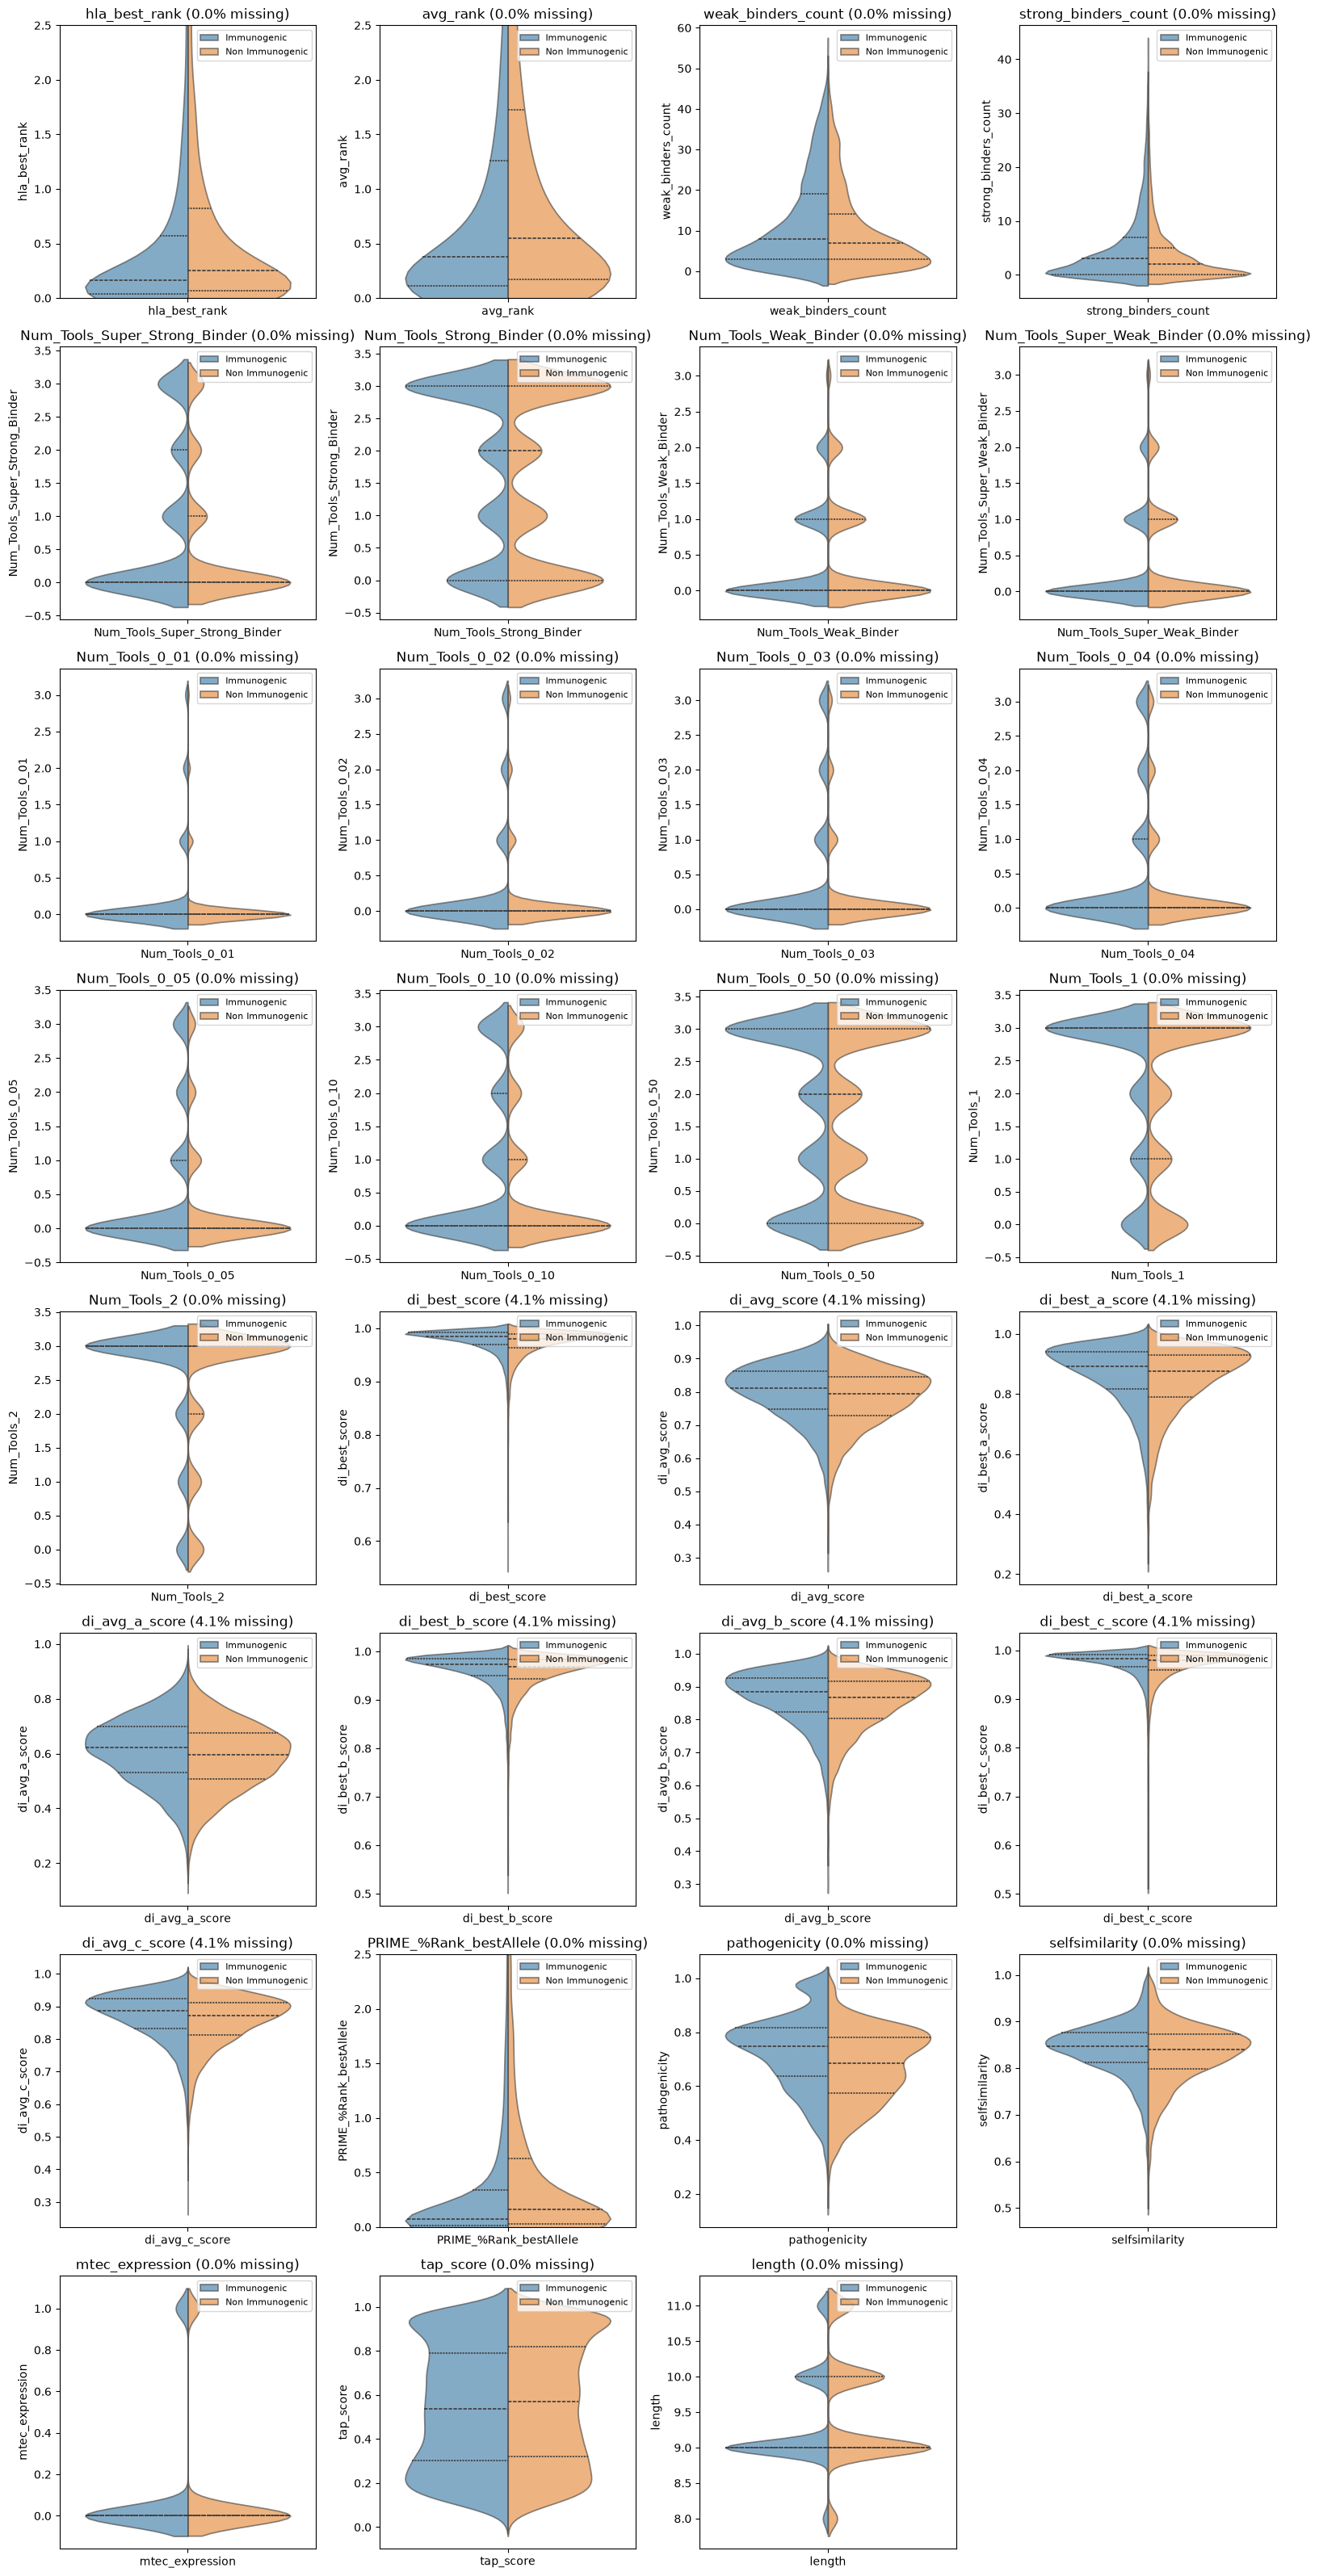

In [17]:
# def plotViolins(X, feature_cols, labels):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         col = X[:, i]
#         not_nan = ~np.isnan(col)

#         # Combine the NaN mask with the class mask
#         data_pos = col[(y == 1) & not_nan]
#         data_neg = col[(y == 0) & not_nan]

#         n_missing = np.isnan(col).sum()
#         pct_missing = 100 * n_missing / len(col)

#         # Restrict range to [0, 5] for '_r' / 'PRIME' features, same as histogram version
#         restrict_range = ('_r' in feature) or ('PRIME' in feature)
#         if restrict_range:
#             data_pos = np.clip(data_pos, 0, 5)
#             data_neg = np.clip(data_neg, 0, 5)

#         parts = axes[i].violinplot(
#             [data_pos, data_neg],
#             positions=[0, 1],
#             showmeans=False,
#             showmedians=True,
#             showextrema=True,
#         )

#         # Color the two violins differently and add alpha, matching hist() style
#         colors = ['C0', 'C1']
#         for body, color in zip(parts['bodies'], colors):
#             body.set_facecolor(color)
#             body.set_alpha(0.6)

#         axes[i].set_xticks([0, 1])
#         axes[i].set_xticklabels(labels)
#         axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
#         axes[i].set_ylabel(feature)

#         if restrict_range:
#             axes[i].set_ylim(0, 2.5)

#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plotViolins(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])

import seaborn as sns
import pandas as pd

def plotViolinsSplit(X, feature_cols, labels):
    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        col = X[:, i]
        not_nan = ~np.isnan(col)
        mask = not_nan & np.isin(y, [0, 1])

        vals = col[mask]
        groups = np.where(y[mask] == 1, labels[0], labels[1])

        n_missing = np.isnan(col).sum()
        pct_missing = 100 * n_missing / len(col)

        restrict_range = ('_r' in feature) or ('PRIME' in feature)
        if restrict_range:
            vals = np.clip(vals, 0, 5)

        df = pd.DataFrame({'value': vals, 'group': groups, 'x': feature})

        sns.violinplot(
            data=df, x='x', y='value', hue='group', split=True,
            ax=axes[i], hue_order=labels, inner='quartile', alpha=0.6
        )
        axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
        axes[i].set_xlabel('')
        axes[i].set_ylabel(feature)
        axes[i].legend(loc='upper right', fontsize=8)

        if restrict_range:
            axes[i].set_ylim(0, 2.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plotViolinsSplit(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])

Index(['best_rank', 'avg_rank', 'strong_binders_count', 'weak_binders_count',
       'Num_Tools_0_05', 'Num_Tools_0_10', 'Num_Tools_0_50', 'di_best_score',
       'di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score',
       'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score',
       'PRIME_%Rank_bestAllele', 'pathogenicity', 'mtec_expression', 'length'],
      dtype='str')


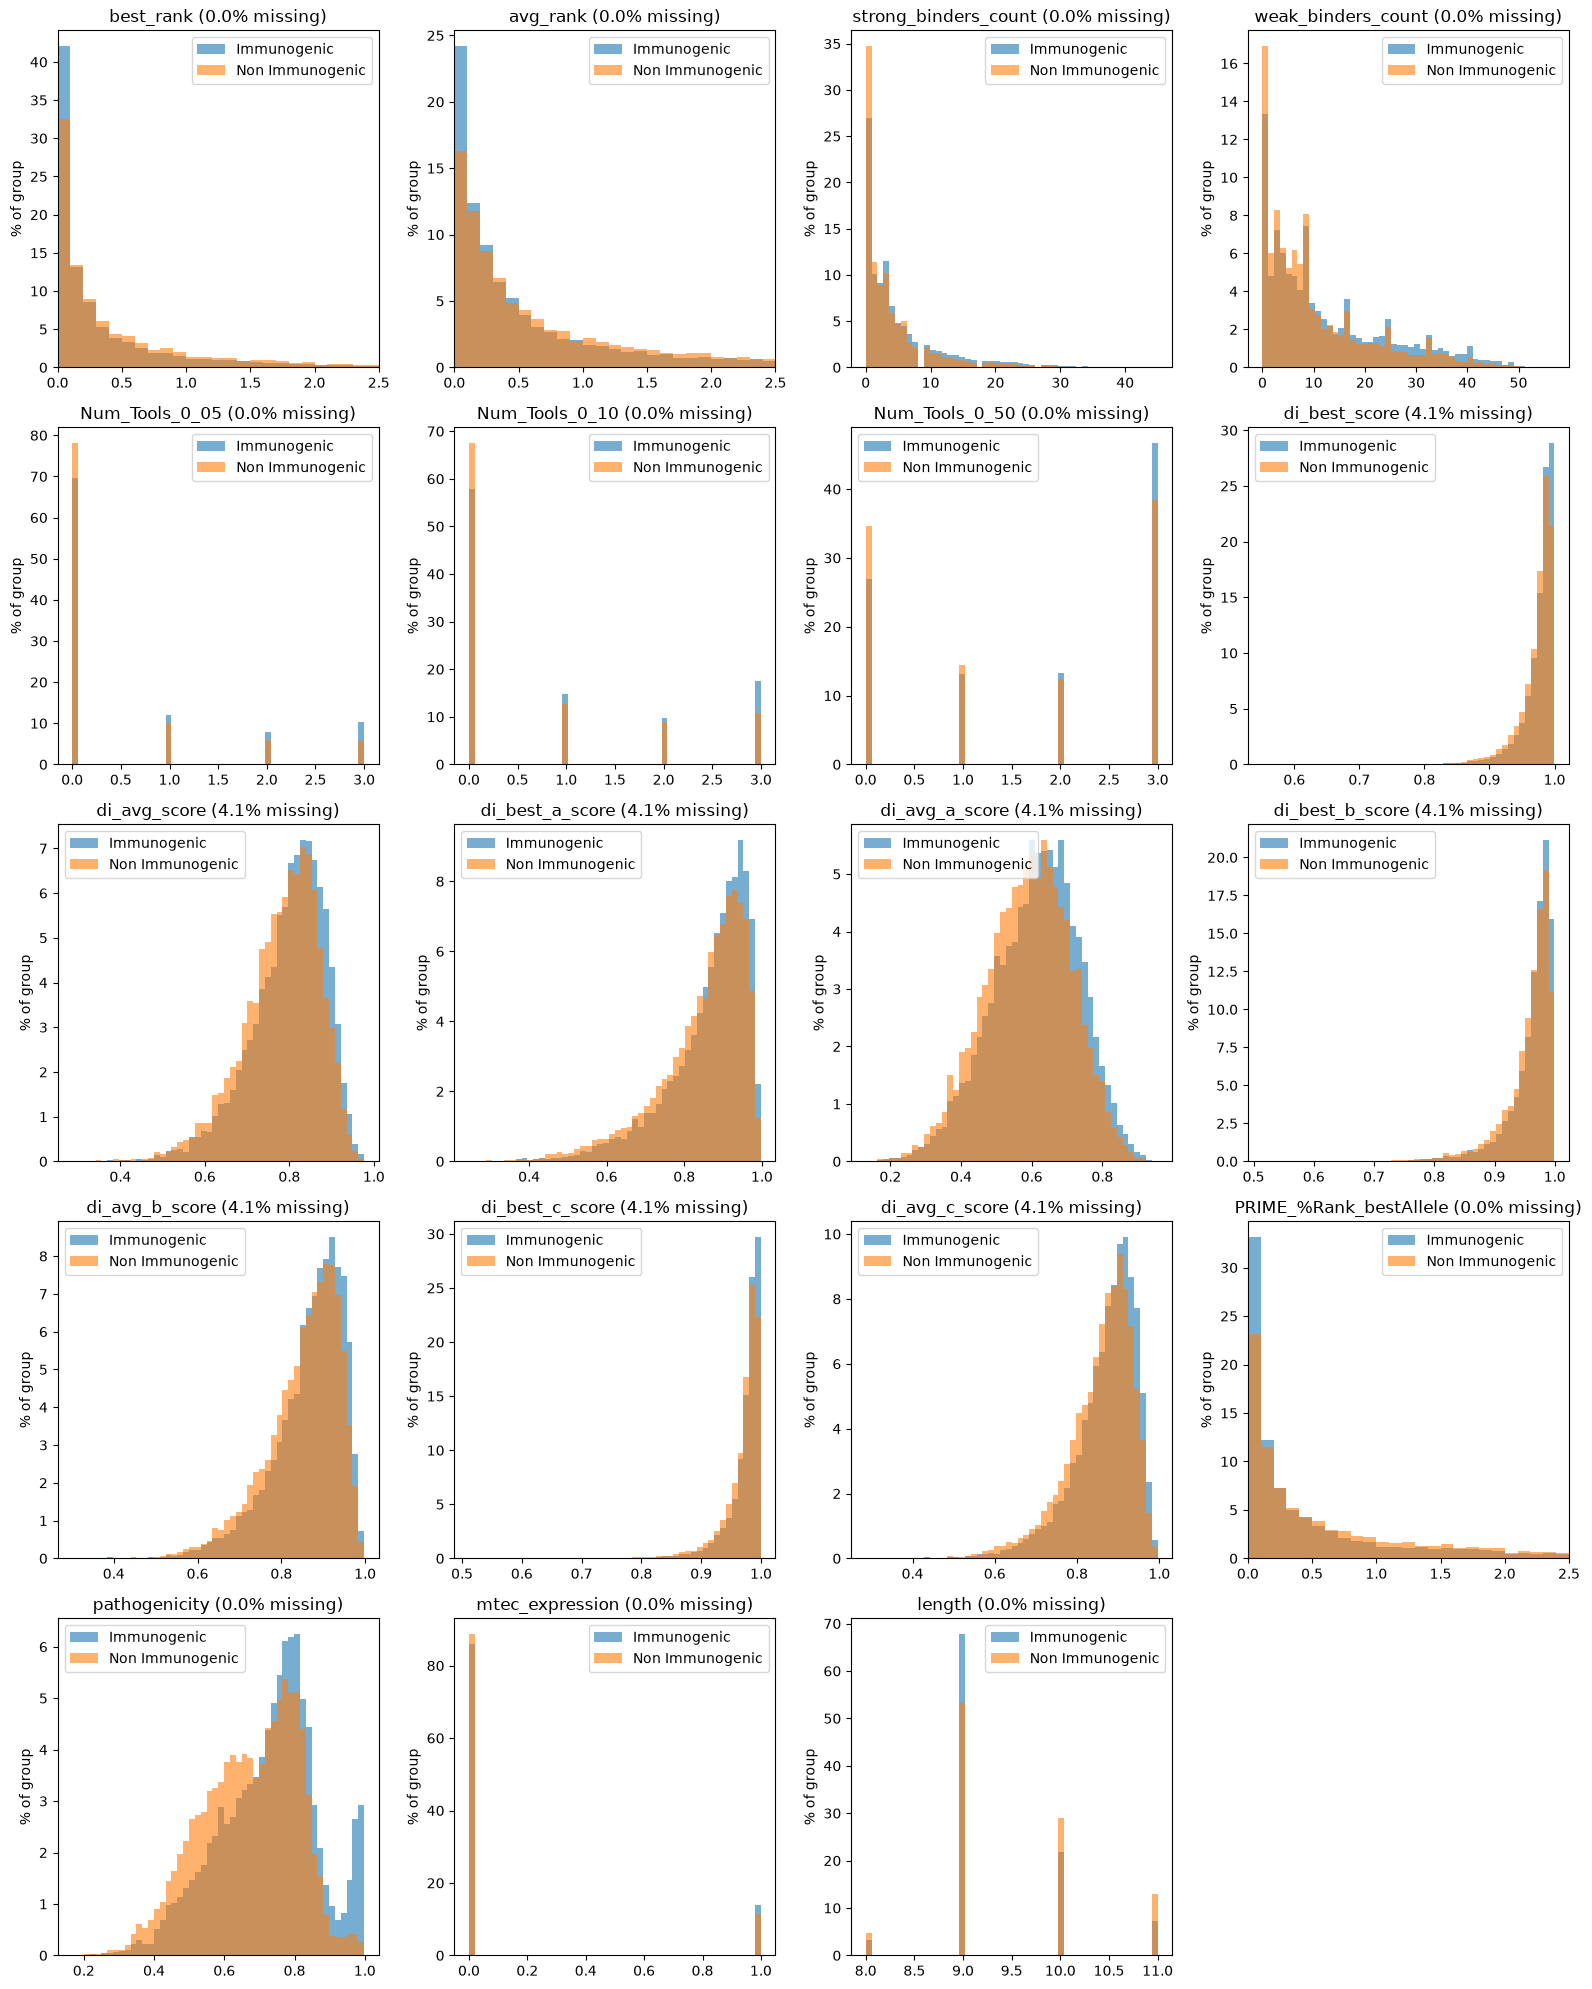

In [ ]:
import numpy as np

def plotHistograms(X, feature_cols, labels):
    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        col = X[:, i]
        not_nan = ~np.isnan(col)

        # Combine the NaN mask with the class mask
        data_pos = col[(y == 1) & not_nan]
        data_neg = col[(y == 0) & not_nan]

        n_missing = np.isnan(col).sum()
        pct_missing = 100 * n_missing / len(col)

        # Restrict x-axis to [0, 5] for '_r' / 'PRIME' features, folding overflow into the last bin
        restrict_range = ('_r' in feature) or ('PRIME' in feature)
        if restrict_range:
            data_pos = np.clip(data_pos, 0, 5)
            data_neg = np.clip(data_neg, 0, 5)
            bins = np.linspace(0, 5, 51)
        else:
            combined = np.concatenate([data_pos, data_neg])
            bins = np.histogram_bin_edges(combined, bins=50)

        weights_pos = np.ones_like(data_pos, dtype=float) * 100.0 / len(data_pos)
        weights_neg = np.ones_like(data_neg, dtype=float) * 100.0 / len(data_neg)

        axes[i].hist(data_pos, bins=bins, weights=weights_pos, alpha=0.6, label=labels[0])
        axes[i].hist(data_neg, bins=bins, weights=weights_neg, alpha=0.6, label=labels[1])
        axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
        axes[i].set_ylabel('% of group')
        if restrict_range:
            axes[i].set_xlim(0, 2.5)
        axes[i].legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plotHistograms(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])

In [431]:
# def plotBoxplots(X, feature_cols):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         data = [X[y == 0, i], X[y == 1, i]]
#         axes[i].boxplot(data, label=['Non-immunogenic', 'Immunogenic'])
#         axes[i].set_title(feature)
#         axes[i].set_ylabel('Value')

#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plotBoxplots(X, feature_cols)

## Feature Scaling

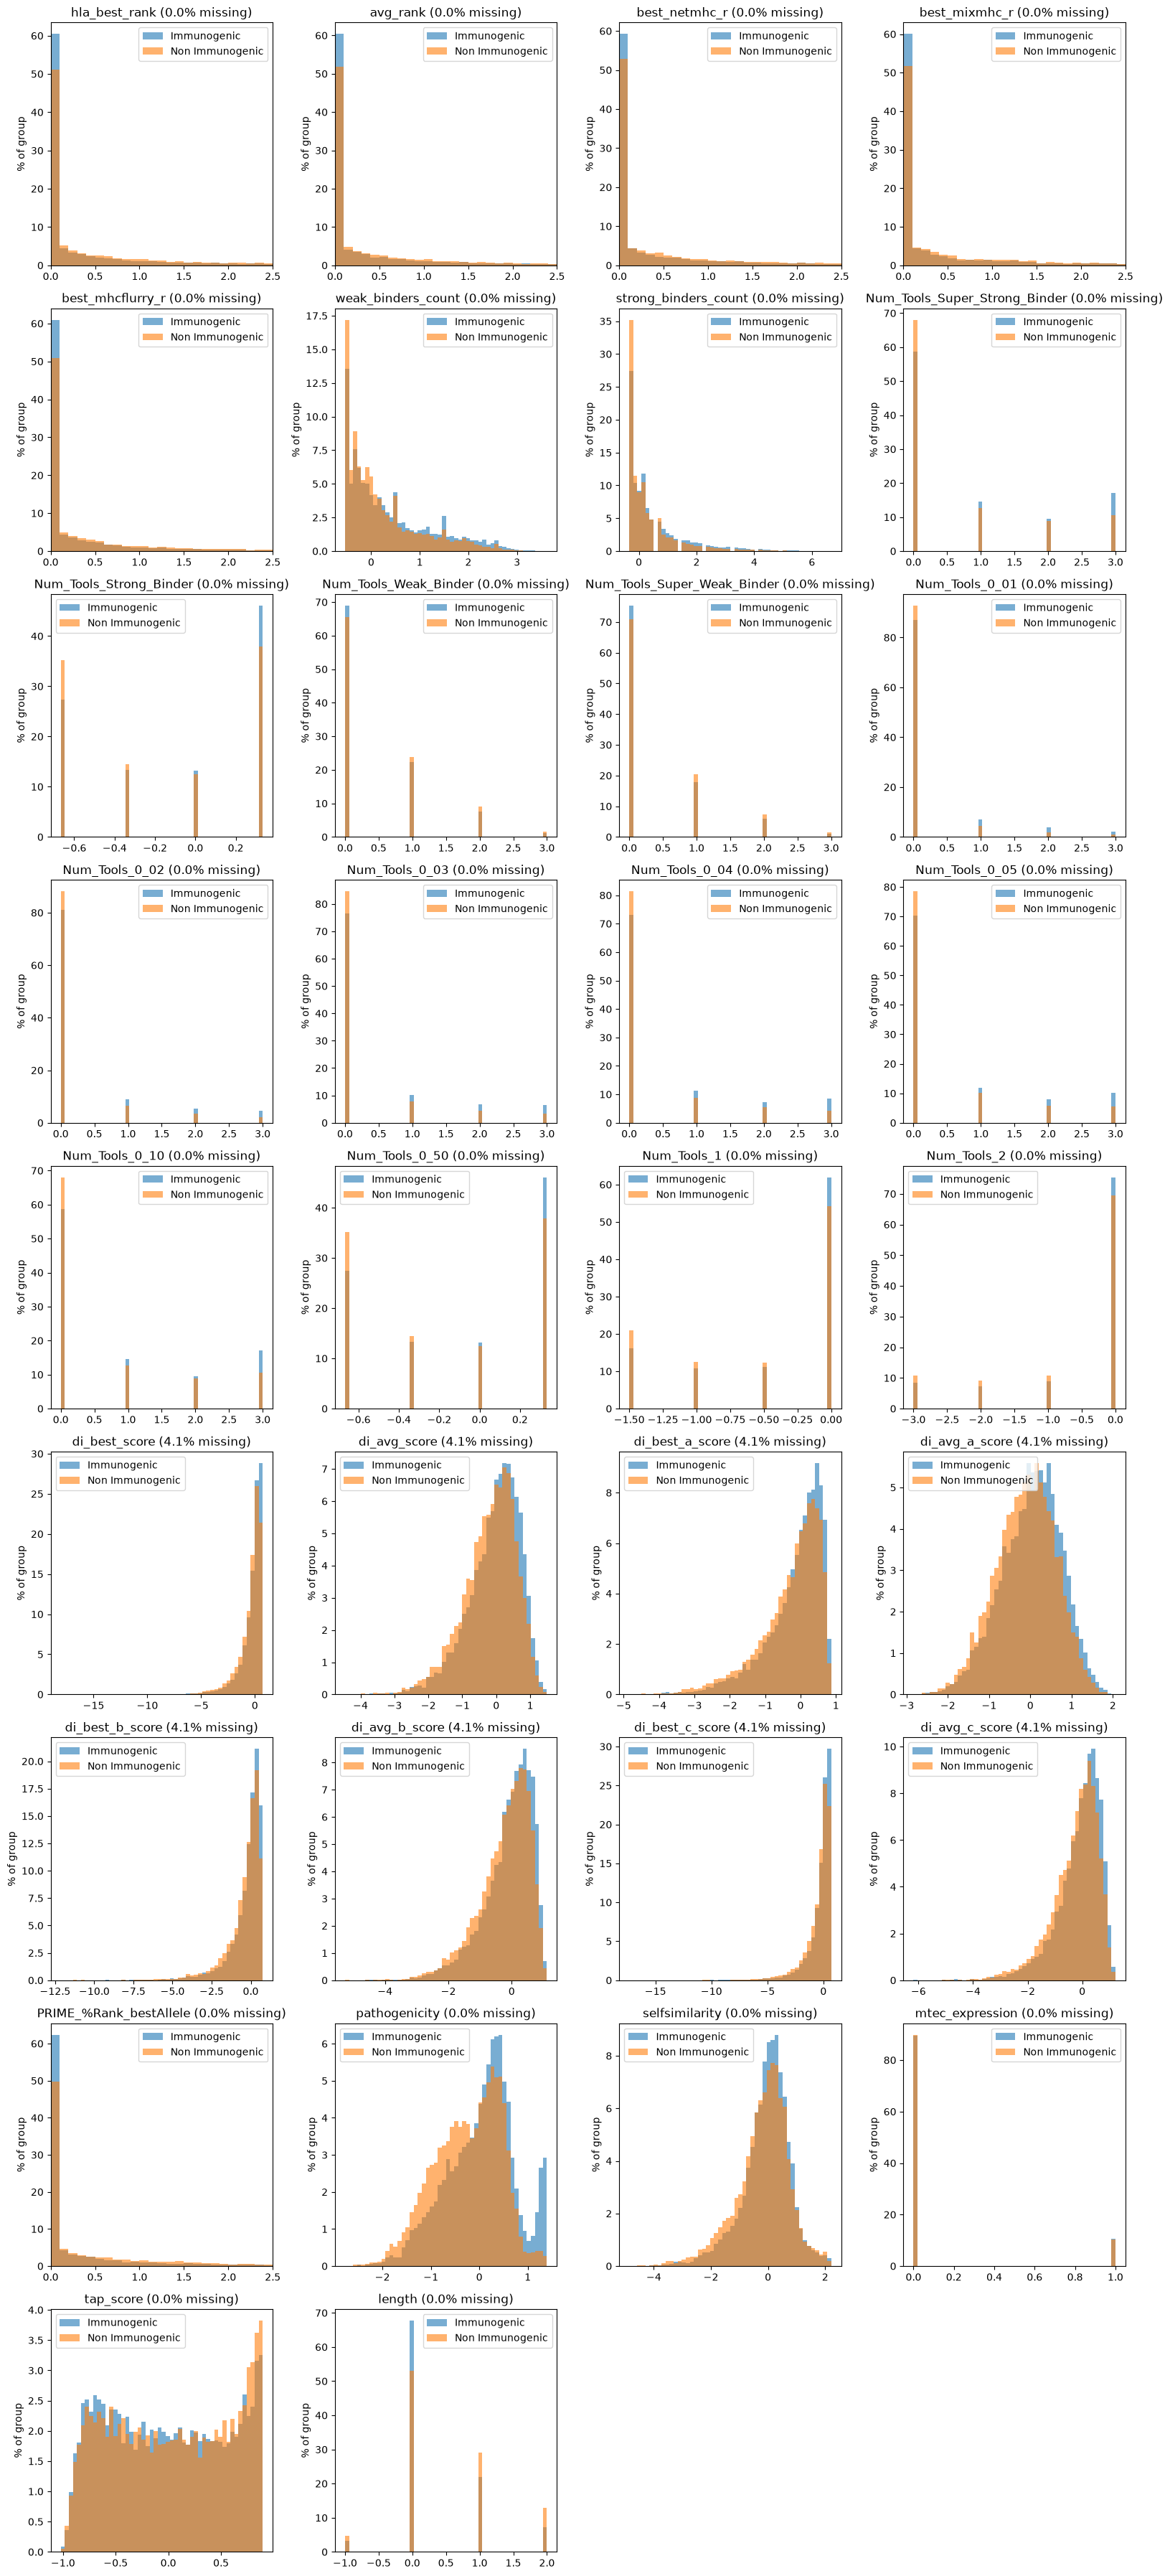

In [ ]:
transformer = RobustScaler().fit(X)
X_scaled_Robust = transformer.transform(X)

#plotBoxplots(X_scaled_Robust, feature_cols)
#plotHistograms(X_scaled_Robust, feature_cols, ['Immunogenic', 'Non Immunogenic'])

In [150]:
# transformer = StandardScaler().fit(X)
# X_scaled_Standard = transformer.transform(X)

# #plotBoxplots(X_scaled_Standard, feature_cols)
# plotHistograms(X_scaled_Standard, feature_cols, ['Immunogenic', 'Non Immunogenic'])

## Train Test Split

### Removing Non-informative features

In [43]:
print("Model Train Test DF:")
display(X_df.shape)

# NB Drops: TAP, selfsimilarity, 
X_df_final = X_df.drop(columns=['Num_Tools_Super_Strong_Binder', 'Num_Tools_Strong_Binder',
       'Num_Tools_Weak_Binder', 'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'tap_score',
       'Num_Tools_0_02', 'Num_Tools_0_03', 'Num_Tools_0_04', 'strong_binders_count','Num_Tools_1', 
       'Num_Tools_2', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 'selfsimilarity'], errors='ignore')

display(X_df_final.shape)
display(X_df_final.columns)

print("Validation DF:")
X_validation_df = X_validation_df.drop(columns=['Num_Tools_Super_Strong_Binder', 'Num_Tools_Strong_Binder',
       'Num_Tools_Weak_Binder', 'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'tap_score',
       'Num_Tools_0_02', 'Num_Tools_0_03', 'Num_Tools_0_04', 'strong_binders_count','Num_Tools_1', 
       'Num_Tools_2', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 'selfsimilarity'], errors='ignore')

display(X_validation_df.shape)

print('X traintest numpy array shape')
X = X_df_final.drop(columns='peptide').to_numpy()
display(X.shape)

print('X_validation numpy array shape')
X_validation = X_validation_df.drop(columns='peptide').to_numpy()
display(X_validation.shape)

print('y traintest shape')
y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y.shape)

transformer = RobustScaler().fit(X)
X_scaled_Robust = transformer.transform(X)

# transformer = RobustScaler().fit(X_validation)
# X_validation_scaled_robust = transformer.transform(X)


Model Train Test DF:


(19499, 35)

(19499, 19)

Index(['peptide', 'hla_best_rank', 'avg_rank', 'weak_binders_count',
       'Num_Tools_0_05', 'Num_Tools_0_10', 'Num_Tools_0_50', 'di_best_score',
       'di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score',
       'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score',
       'PRIME_%Rank_bestAllele', 'pathogenicity', 'mtec_expression', 'length'],
      dtype='str')

Validation DF:


(22837, 10)

X traintest numpy array shape


(19499, 18)

X_validation numpy array shape


(22837, 9)

y traintest shape


(19499,)

In [71]:
FINAL_FEATURES = X_df_final.columns

In [44]:
assert len(X_df) == X.shape[0] == len(y)

## Train Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"X_train: {X_train.shape}")
display(f"X_test: {X_test.shape}")
display(f"y_train: {y_train.shape}")
display(f"y_test: {y_test.shape}")

X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled_Robust, y, test_size=0.2, random_state=42)

'X_train: (15599, 18)'

'X_test: (3900, 18)'

'y_train: (15599,)'

'y_test: (3900,)'

## Feature Importance

#### RidgeCV

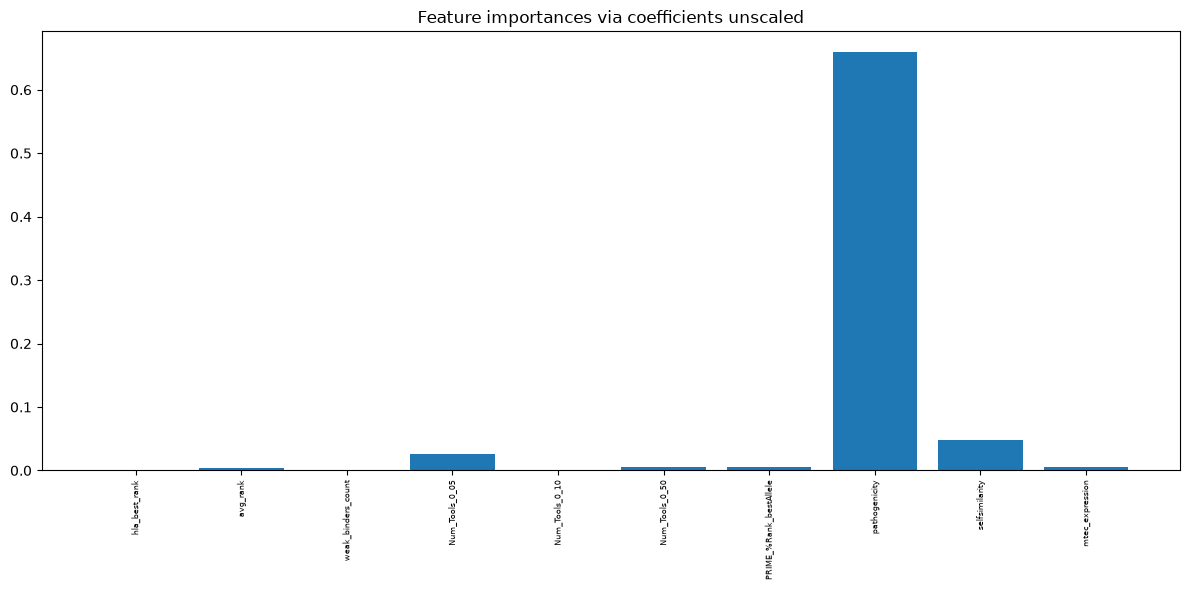

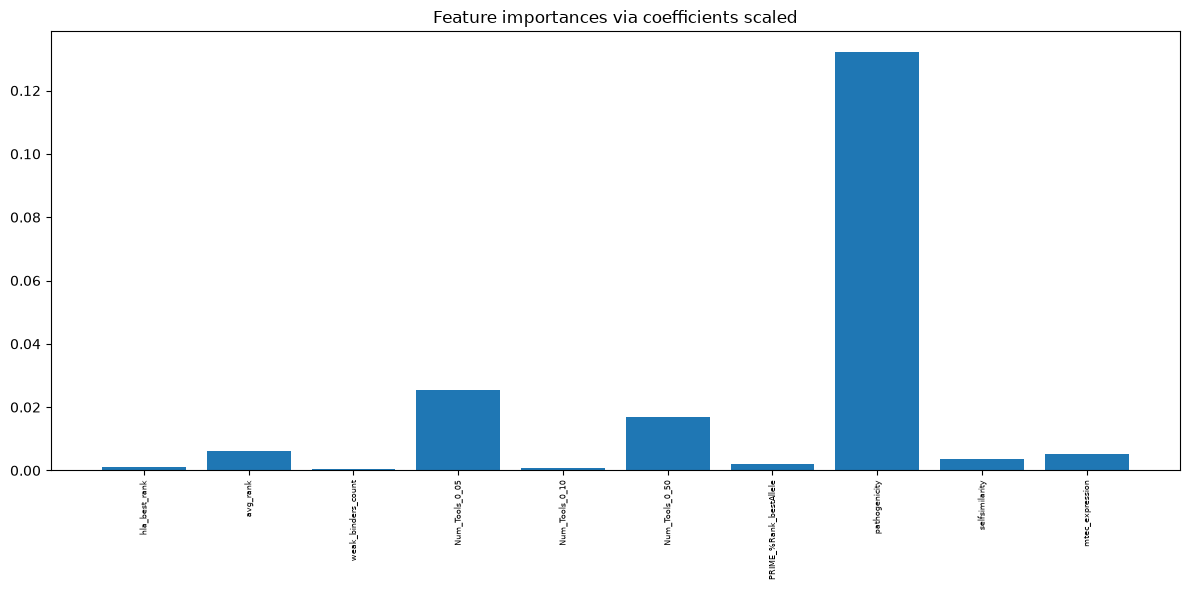

In [132]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X_train, y_train)
ridge_scaled = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X_scaled_train, y_train)
importance = np.abs(ridge.coef_)
importance_scaled = np.abs(ridge_scaled.coef_)

colnames = X_df_final.columns
feature_names = np.array(colnames.drop('peptide'))

plt.figure(figsize=(12, 6))
plt.bar(height=importance, x=feature_names)
plt.title("Feature importances via coefficients unscaled")
plt.xticks(rotation=90, fontsize=6, ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(height=importance_scaled, x=feature_names)
plt.title("Feature importances via coefficients scaled")
plt.xticks(rotation=90, fontsize=6, ha='center')
plt.tight_layout()
plt.show()

#### Sequential Feature Selection

In [572]:
from sklearn.feature_selection import SequentialFeatureSelector

def print_sfs_features(X, y, label: str):
    print(f'{label} dataset')  
    #tic_fwd = time()
    sfs_forward = SequentialFeatureSelector(
        ridge, n_features_to_select=5, direction="forward"
    ).fit(X, y)
    #toc_fwd = time()

    #tic_bwd = time()
    sfs_backward = SequentialFeatureSelector(
        ridge, n_features_to_select=5, direction="backward"
    ).fit(X, y)
    #toc_bwd = time()

    print(
        "Features selected by forward sequential selection: "
        f"{feature_names[sfs_forward.get_support()]}"
    )
    # print(f"Done in {toc_fwd - tic_fwd:.3f}s")
    print(
        "Features selected by backward sequential selection: "
        f"{feature_names[sfs_backward.get_support()]}"
    )
    # print(f"Done in {toc_bwd - tic_bwd:.3f}s")
    print('-'*60)

print_sfs_features(X_train, y_train, 'Standard')
print_sfs_features(X_scaled_train, y_train, 'Scaled')

Standard dataset
Features selected by forward sequential selection: ['weak_binders_count' 'Num_Tools_0_10' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity']
Features selected by backward sequential selection: ['weak_binders_count' 'Num_Tools_0_05' 'Num_Tools_1' 'pathogenicity'
 'selfsimilarity']
------------------------------------------------------------
Scaled dataset
Features selected by forward sequential selection: ['weak_binders_count' 'Num_Tools_0_10' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity']
Features selected by backward sequential selection: ['weak_binders_count' 'Num_Tools_0_05' 'Num_Tools_1' 'pathogenicity'
 'selfsimilarity']
------------------------------------------------------------


#### Tree-based feature selection

(15599, 14)

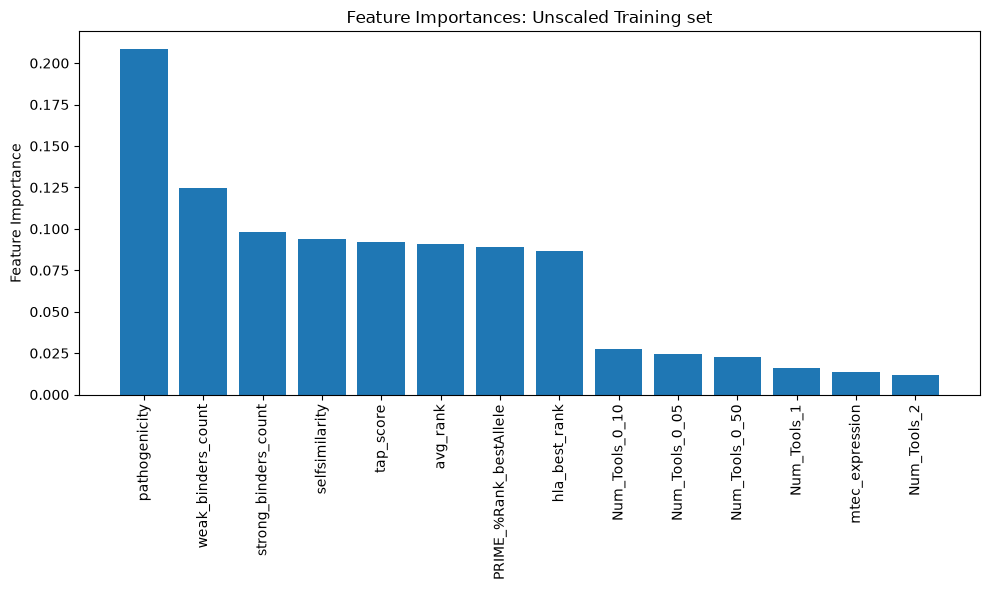

'Selected model shape: (15599, 8)'

(15599, 14)

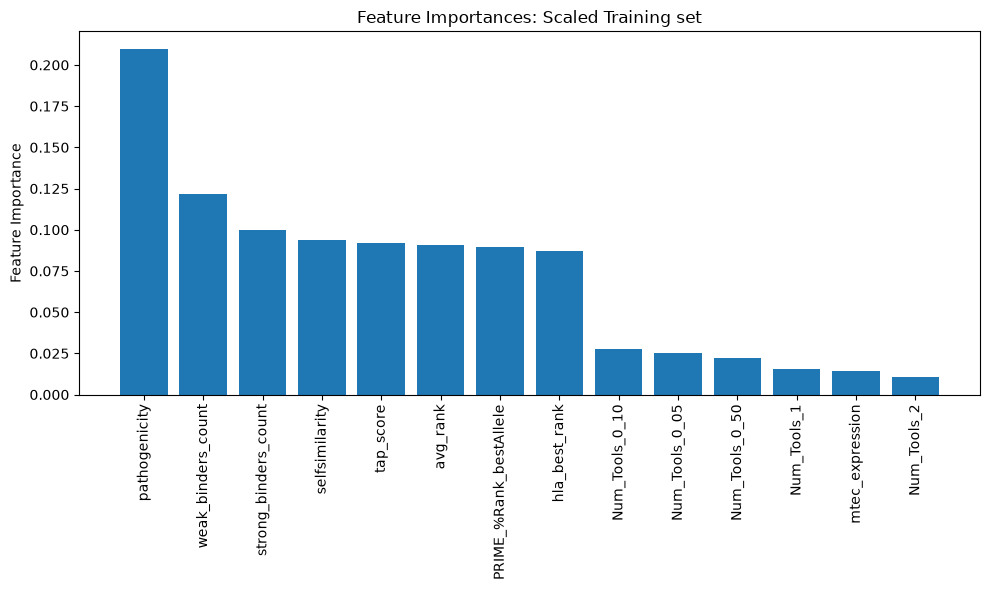

'Selected model shape: (15599, 8)'

In [575]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt

def plotTreeBasedFeatImportance(X, y, scaled):
    display(X.shape)

    clf = ExtraTreesClassifier(n_estimators=50)
    clf = clf.fit(X_train, y_train)
        
    # for col, imp in zip(X_df_final.drop(columns=['peptide']).columns, clf.feature_importances_):
    #     print(f"{col}: {imp}")

    cols = feature_names
    importances = clf.feature_importances_

    # Sort by importance, descending
    sorted_idx = importances.argsort()[::-1]
    sorted_cols = [cols[i] for i in sorted_idx]
    sorted_imp = importances[sorted_idx]

    plt.figure(figsize=(10, 6))
    plt.bar(sorted_cols, sorted_imp)
    plt.xticks(rotation=90)
    plt.ylabel("Feature Importance")
    plt.title(f"Feature Importances: {scaled}")
    plt.tight_layout()
    plt.show()


    model = SelectFromModel(clf, prefit=True)
    X_new = model.transform(X)
    display(f"Selected model shape: {X_new.shape}")

plotTreeBasedFeatImportance(X_train, y_train, "Unscaled Training set")
plotTreeBasedFeatImportance(X_scaled_train, y_train, "Scaled Training set")

#### L1-based feature selection

(15599, 14)

(15599, 13)

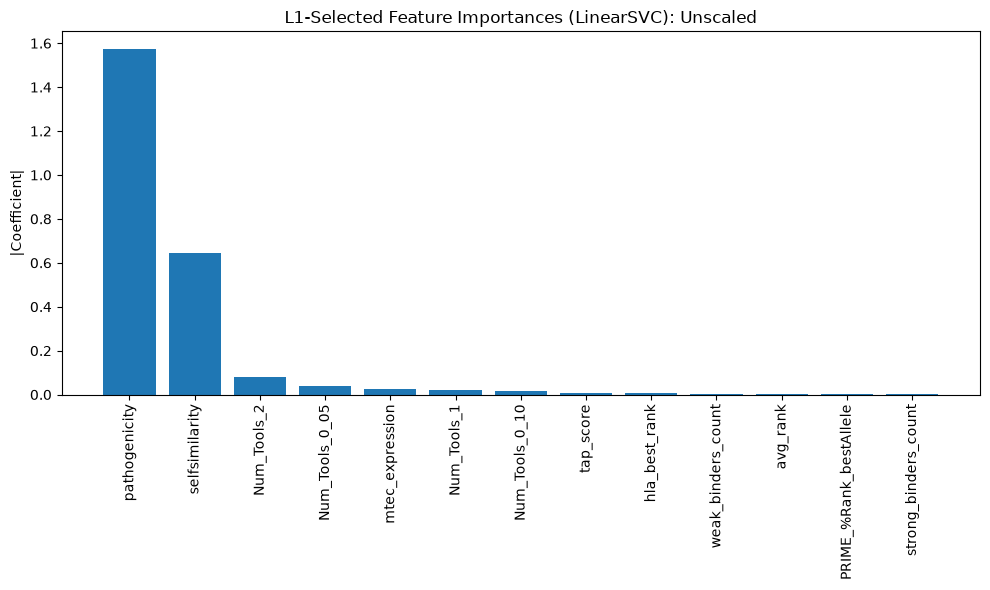

(15599, 14)

(15599, 11)

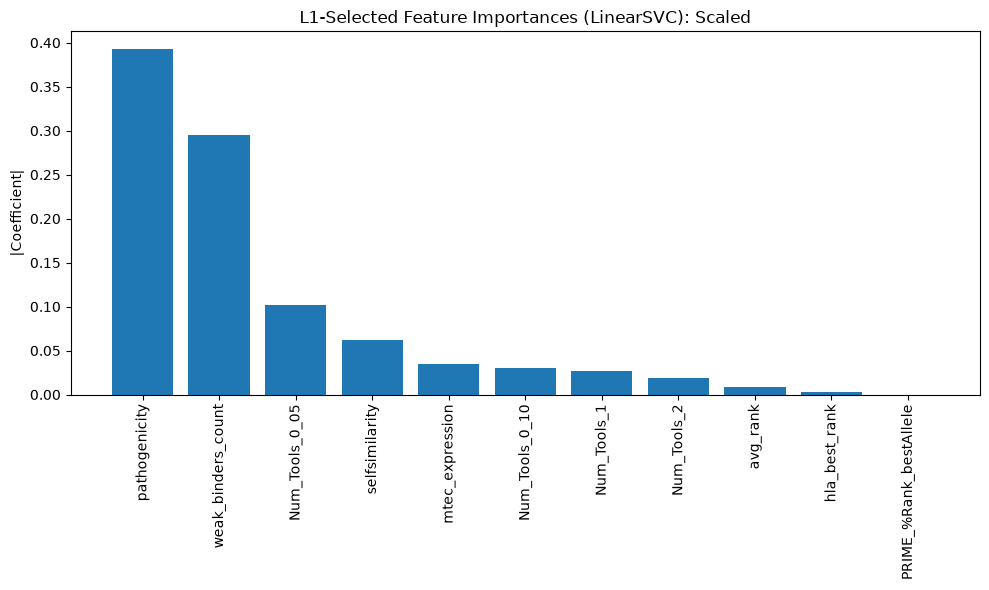

In [578]:
from sklearn.svm import LinearSVC

def plotL1LinearSVCFeatureSelection(X, y, label):
    display(X.shape)

    lsvc = LinearSVC(C=0.01, penalty="l1", dual=False).fit(X, y)
    model = SelectFromModel(lsvc, prefit=True)
    X_new = model.transform(X)
    display(X_new.shape)

    # importances = np.abs(lsvc.coef_[0])
    # for col, imp in zip(X_df_final.drop(columns=['peptide']).columns, importances):
    #     print(f"{col}: {imp}")

    import matplotlib.pyplot as plt

    mask = model.get_support()
    selected_cols = feature_names[mask]
    selected_importances = np.abs(lsvc.coef_[0])[mask]  # binary case

    sorted_idx = selected_importances.argsort()[::-1]
    sorted_cols = [selected_cols[i] for i in sorted_idx]
    sorted_imp = selected_importances[sorted_idx]

    plt.figure(figsize=(10, 6))
    plt.bar(sorted_cols, sorted_imp)
    plt.xticks(rotation=90)
    plt.ylabel("|Coefficient|")
    plt.title(f"L1-Selected Feature Importances (LinearSVC): {label}")
    plt.tight_layout()
    plt.show()

plotL1LinearSVCFeatureSelection(X_train, y_train, "Unscaled")
plotL1LinearSVCFeatureSelection(X_scaled_train, y_train, "Scaled")

#### Recursive Feature Elimination with Cross Validation

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold

min_features_to_select = 2  # Minimum number of features to consider
clf = LinearSVC(C=0.01)
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="precision",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)

rfecv.fit(X_train, y_train)
print(f"Optimal number of features Unscaled: {rfecv.n_features_}")

rfecv_scaled = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="precision",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv_scaled.fit(X_scaled_train, y_train)
print(f"Optimal number of features Scaled: {rfecv_scaled.n_features_}")

Optimal number of features Unscaled: 13
Optimal number of features Unscaled: 9


In [616]:
def getRFECfeatNames(rfec, label):
    feat = rfec.get_feature_names_out()
    for i, s in enumerate(feat):
        feat[i] = feature_names[int(s[1:])]

    print(f'{label}')
    print('-'*60)
    print(feat)
    # print(rfec.get_feature_names_out())
    # print(feature_names)
    print('-'*60)

getRFECfeatNames(rfecv, "unscaled")
getRFECfeatNames(rfecv_scaled, "scaled")

unscaled
------------------------------------------------------------
['hla_best_rank' 'avg_rank' 'weak_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_0_50' 'Num_Tools_1' 'Num_Tools_2'
 'PRIME_%Rank_bestAllele' 'pathogenicity' 'selfsimilarity'
 'mtec_expression' 'tap_score']
------------------------------------------------------------
scaled
------------------------------------------------------------
['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_1' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity' 'mtec_expression']
------------------------------------------------------------


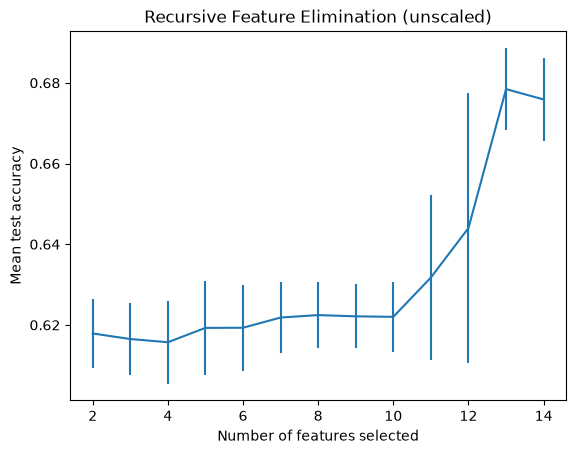

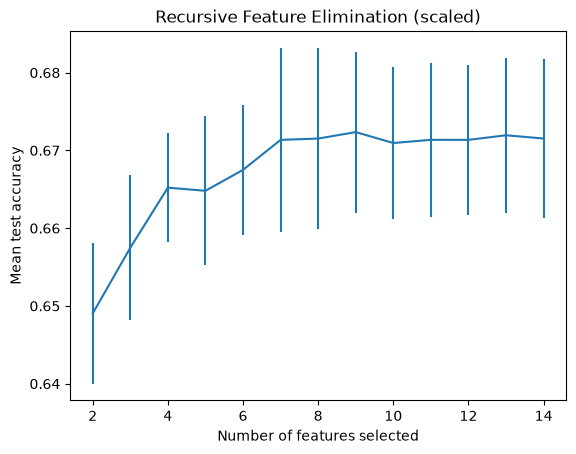

In [584]:
import matplotlib.pyplot as plt
import pandas as pd

def plotRFECV(rfecv, scaled):
    data = {
        key: value
        for key, value in rfecv.cv_results_.items()
        if key in ["n_features", "mean_test_score", "std_test_score"]
    }
    cv_results = pd.DataFrame(data)
    plt.figure()
    plt.xlabel("Number of features selected")
    plt.ylabel("Mean test accuracy")
    plt.errorbar(
        x=cv_results["n_features"],
        y=cv_results["mean_test_score"],
        yerr=cv_results["std_test_score"],
    )
    plt.title(f"Recursive Feature Elimination ({scaled})")
    plt.show()

plotRFECV(rfecv, "unscaled")
plotRFECV(rfecv_scaled, "scaled")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"X_train: {X_train.shape}")
display(f"X_test: {X_test.shape}")
display(f"y_train: {y_train.shape}")
display(f"y_test: {y_test.shape}")

X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled_Robust, y, test_size=0.2, random_state=42)

'X_train: (15599, 22)'

'X_test: (3900, 22)'

'y_train: (15599,)'

'y_test: (3900,)'

In [585]:
import numpy as np
print(f"Scaled Features across {cv.n_splits} folds")

for i in range(cv.n_splits):
    mask = rfecv_scaled.cv_results_[f"split{i}_support"][
        rfecv_scaled.n_features_ - 1
    ]  # mask of features selected by the RFE
    features_selected = np.ma.compressed(np.ma.masked_array(X_df_final.drop(columns=['peptide']).columns, mask=1 - mask))
    print(f"Features selected in fold {i} ({len(features_selected)}): {features_selected}")

Scaled Features across 5 folds
Features selected in fold 0 (10): ['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_1' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity' 'mtec_expression' 'tap_score']
Features selected in fold 1 (10): ['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_0_50' 'Num_Tools_1' 'Num_Tools_2'
 'pathogenicity' 'selfsimilarity' 'mtec_expression']
Features selected in fold 2 (10): ['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_0_50' 'Num_Tools_1' 'Num_Tools_2'
 'pathogenicity' 'selfsimilarity' 'mtec_expression']
Features selected in fold 3 (10): ['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_1' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity' 'mtec_expression' 'tap_score']
Features selected in fold 4 (10): ['weak_binders_count' 'strong_binders_count' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_1' 'Nu

#### Random Forest Feature Importance

In [46]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

feature_names = X_df_final.drop(columns=['peptide']).columns
forest = RandomForestClassifier(random_state=0)
forest_scaled = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)
forest_scaled.fit(X_scaled_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [47]:
import numpy as np

def getImportances(forest):
    importances = forest.feature_importances_
    std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
    return importances, std

importances, std = getImportances(forest)
importances_sc, std_sc = getImportances(forest_scaled)


Feature Importance based on Mean Decrease in Impurity (MDI)

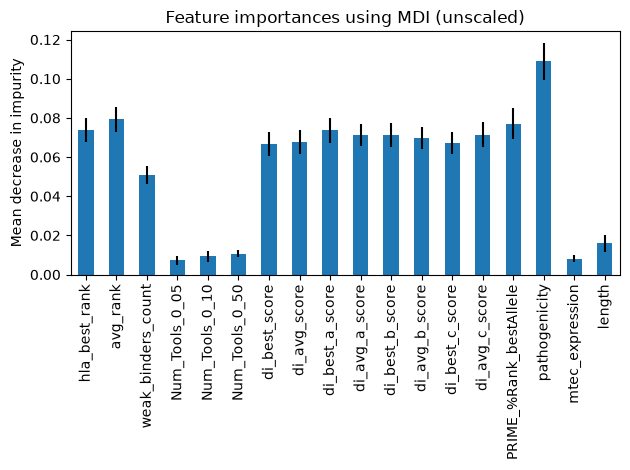

In [48]:
import pandas as pd

def plotForestMDIFeatureImportance(forest, importances, std, scaled):
    forest_importances = pd.Series(importances, index=feature_names)

    fig, ax = plt.subplots()
    forest_importances.plot.bar(yerr=std, ax=ax)
    ax.set_title(f"Feature importances using MDI ({scaled})")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()

plotForestMDIFeatureImportance(forest, importances, std, "unscaled")
#plotForestMDIFeatureImportance(forest_scaled, importances_sc, std_sc, "scaled")

Feature Importance based on feature permutation

In [275]:
from sklearn.inspection import permutation_importance

def getForestPermutationFeatureImportance(forest, X, y):
    result = permutation_importance(
        forest, X, y, n_repeats=10, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=feature_names)

    return result, forest_importances

result, forest_importances = getForestPermutationFeatureImportance(forest, X_train, y_train)
result_sc, forest_importances_sc = getForestPermutationFeatureImportance(forest_scaled, X_scaled_train, y_train)

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


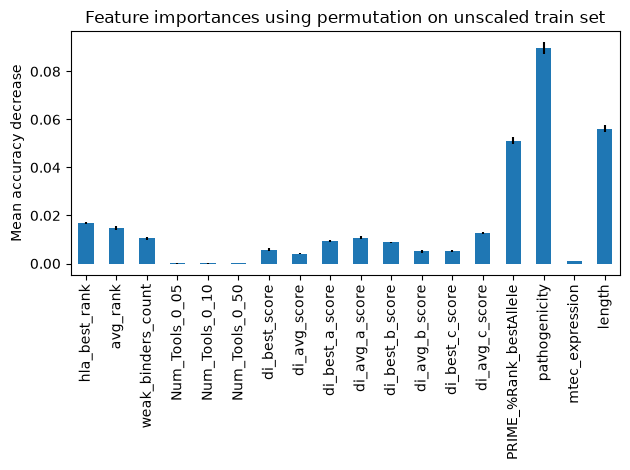

In [277]:
def plotForestPermutationFeatureImportance(result, scaled):
    fig, ax = plt.subplots()
    forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
    ax.set_title(f"Feature importances using permutation on {scaled} train set")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

plotForestPermutationFeatureImportance(result, "unscaled")
#plotForestPermutationFeatureImportance(result, "scaled")

#### Univariate Feature Selection
does not work

In [595]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=20)
selector.fit(X_scaled_train, y_train)
scores = -np.log10(selector.pvalues_)
scores /= scores.max()

/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=14. All the features will be returned.
  warnings.warn(
/var/folders/3l/3p0t5hpd41nftsr1xnzqh0wc0000gn/T/ipykernel_85079/1140974425.py:5: RuntimeWarning: divide by zero encountered in log10
  scores = -np.log10(selector.pvalues_)
/var/folders/3l/3p0t5hpd41nftsr1xnzqh0wc0000gn/T/ipykernel_85079/1140974425.py:6: RuntimeWarning: invalid value encountered in divide
  scores /= scores.max()


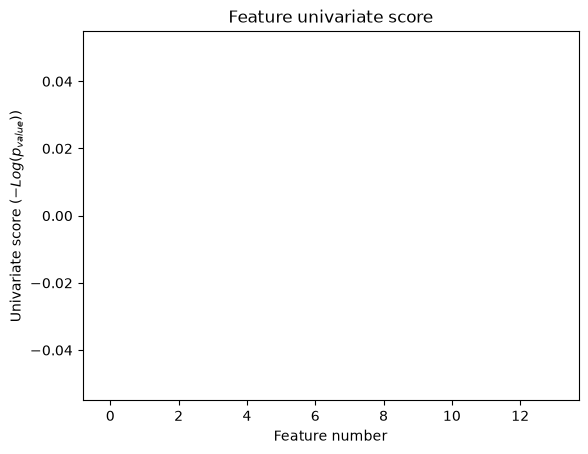

In [596]:
import matplotlib.pyplot as plt

X_indices = np.arange(X.shape[-1])
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, scores, width=0.2)
plt.title("Feature univariate score")
plt.xlabel("Feature number")
plt.ylabel(r"Univariate score ($-Log(p_{value})$)")
plt.show()

## Model

In [ ]:
# from sklearn import svm
# from sklearn.model_selection import KFold, GridSearchCV
# from sklearn.pipeline import Pipeline
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# param_grid_linear = {"svc__C": [0.1, 1, 10]}
# param_grid_rbf    = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]}

# pipe_linear = Pipeline([("svc", svm.LinearSVC(random_state=0, max_iter=10000))])
# pipe_rbf    = Pipeline([("svc", svm.SVC(kernel="rbf", random_state=0))])

# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# datasets = {
#     "unscaled": X,
#     "scaled_robust": X_scaled_Robust,
# }

# model_configs = {
#     "linear": (pipe_linear, param_grid_linear),
#     "rbf":    (pipe_rbf, param_grid_rbf),
# }

# scoring = {
#     "accuracy": "accuracy",
#     "balanced_accuracy": "balanced_accuracy",
#     "precision_macro": "precision_macro",
#     "recall_macro": "recall_macro",
#     "f1_macro": "f1_macro",
# }
# REFIT_METRIC = "precision_macro"  # which metric selects best_params_

# # ------------------------------------------------------------------
# # Run GridSearchCV for every (model, dataset) combination
# # ------------------------------------------------------------------
# results = []

# for data_name, X_data in datasets.items():
#     for model_name, (pipe, grid) in model_configs.items():
#         clf = GridSearchCV(
#             estimator=pipe,
#             param_grid=grid,
#             cv=cv,
#             scoring=scoring,
#             refit=REFIT_METRIC,
#             n_jobs=-1,
#             return_train_score=True,
#         )
#         clf.fit(X_data, y)

#         best_index = clf.best_index_

#         # one row per fold per metric, for the best (precision-selected) params
#         for metric_name in scoring:
#             fold_scores = [
#                 clf.cv_results_[f"split{i}_test_{metric_name}"][best_index]
#                 for i in range(cv.get_n_splits())
#             ]
#             for fold_idx, score in enumerate(fold_scores):
#                 results.append({
#                     "model": model_name,
#                     "dataset": data_name,
#                     "fold": fold_idx,
#                     "metric": metric_name,
#                     "score": score,
#                     "best_params": str(clf.best_params_),
#                 })

# results_df = pd.DataFrame(results)
# print(results_df)

     model        dataset  fold    metric     score  \
0   linear       unscaled     0  accuracy  0.656764   
1   linear       unscaled     1  accuracy  0.654556   
2   linear       unscaled     2  accuracy  0.657166   
3   linear       unscaled     3  accuracy  0.658302   
4   linear       unscaled     4  accuracy  0.658101   
..     ...            ...   ...       ...       ...   
95     rbf  scaled_robust     0  f1_macro  0.606890   
96     rbf  scaled_robust     1  f1_macro  0.591575   
97     rbf  scaled_robust     2  f1_macro  0.600295   
98     rbf  scaled_robust     3  f1_macro  0.594771   
99     rbf  scaled_robust     4  f1_macro  0.606790   

                         best_params  
0                      {'svc__C': 1}  
1                      {'svc__C': 1}  
2                      {'svc__C': 1}  
3                      {'svc__C': 1}  
4                      {'svc__C': 1}  
..                               ...  
95  {'svc__C': 1, 'svc__gamma': 0.1}  
96  {'svc__C': 1, 'svc__gam

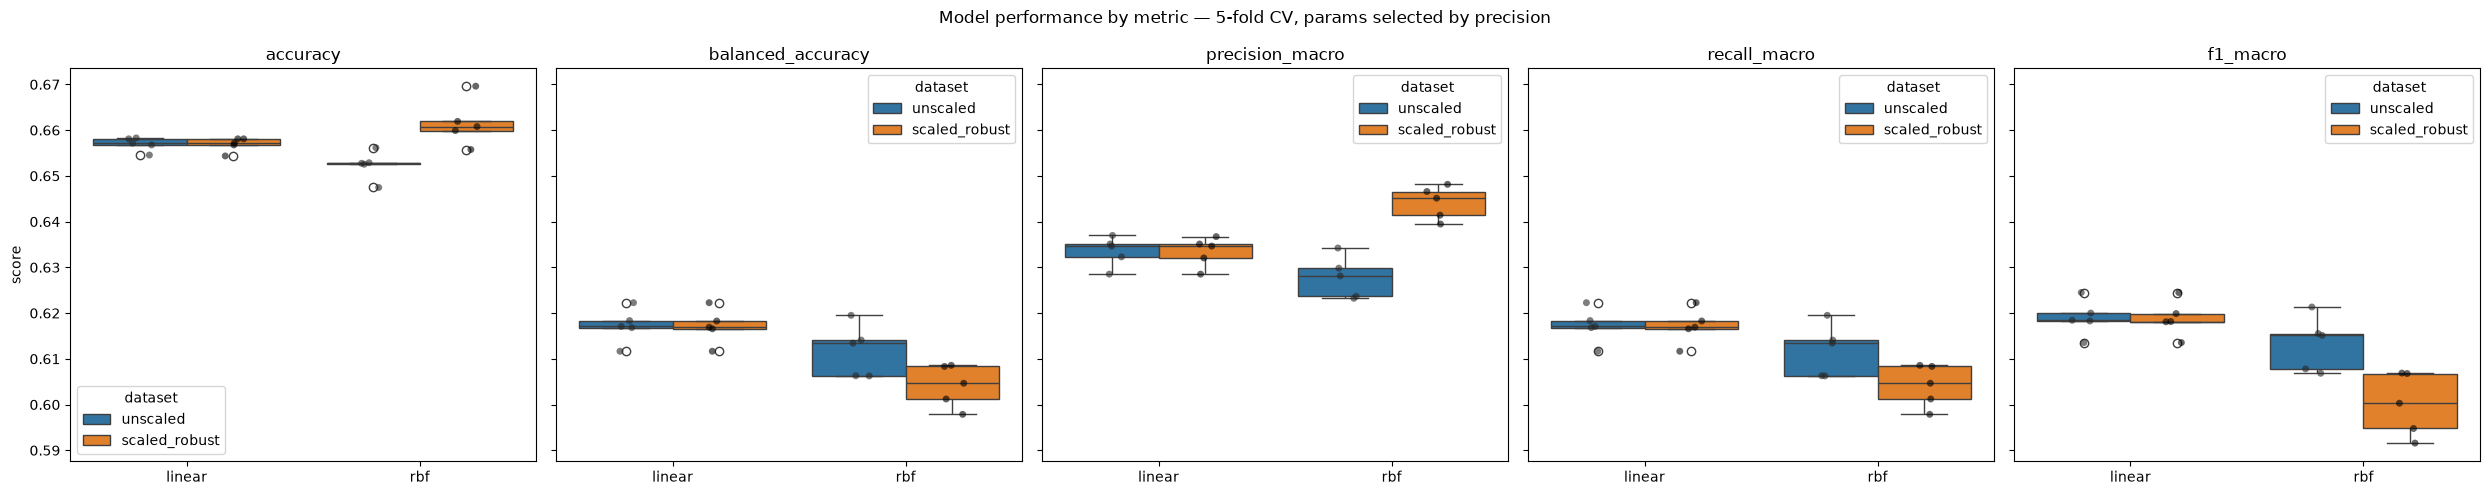

In [391]:
# plt.figure(figsize=(8, 5))
# sns.boxplot(data=results_df, x="model", y="precision_macro", hue="dataset")
# sns.stripplot(
#     data=results_df, x="model", y="precision_macro", hue="dataset",
#     dodge=True, palette='dark:black', size=5, alpha=0.6, legend=False
# )
# plt.title("Precision (macro) by model and scaling — 5-fold CV, best params per fold")
# plt.show()
def plotModels(results_df):
    metrics = results_df["metric"].unique()
    n_metrics = len(metrics)

    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5), sharey=True)

    if n_metrics == 1:
        axes = [axes]  # keep axes iterable if there's only one metric

    for ax, metric_name in zip(axes, metrics):
        subset = results_df[results_df["metric"] == metric_name]

        sns.boxplot(data=subset, x="model", y="score", hue="dataset", ax=ax)
        sns.stripplot(
            data=subset, x="model", y="score", hue="dataset",
            dodge=True, palette="dark:black", size=5, alpha=0.6,
            legend=False, ax=ax
        )
        ax.set_title(metric_name)
        ax.set_xlabel("")
        ax.set_ylabel("score" if ax == axes[0] else "")

    plt.suptitle("Model performance by metric — 5-fold CV, params selected by precision")
    plt.tight_layout()
    plt.show()

plotModels(results_df)

#### Best Params

In [49]:
#print(results_df[results_df['model'] == 'rbf'])

print("RBF Kernel best params:")
print("C = 1")
print("Gamma = 0.1")

RBF Kernel best params:
C = 1
Gamma = 0.1


In [50]:
from sklearn import svm
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np

import os
os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1'

# ------------------------------------------------------------------
# Pipeline: impute (fold-specific) -> scale (fold-specific) -> RBF SVM
# ------------------------------------------------------------------
pipe_rbf_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
    ("svc", svm.SVC(kernel="rbf", C=1, gamma=0.1, random_state=0)),
])

# ------------------------------------------------------------------
# Composite stratification key: class label + exact peptide length
# ------------------------------------------------------------------
assert len(X_df) == X.shape[0] == len(y)  # sanity check alignment

lengths = X_df['length'].to_numpy()
strata = pd.Series(y).astype(str) + "_" + pd.Series(lengths).astype(str)

strata_counts = strata.value_counts()
print("Smallest stratum sizes:")
print(strata_counts.sort_values().head(10))

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
svm_fold_indices = list(cv.split(X, strata))

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

# ------------------------------------------------------------------
# Run cross_validate
# ------------------------------------------------------------------
scores = cross_validate(
    estimator=pipe_rbf_scaled,
    X=X,
    y=y,
    cv=svm_fold_indices,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
)

results_rbf = []
for metric_name in scoring:
    fold_scores = scores[f"test_{metric_name}"]
    for fold_idx, score in enumerate(fold_scores):
        results_rbf.append({
            "model": "rbf_scaled",
            "fold": fold_idx,
            "metric": metric_name,
            "score": score,
            "params": "C=1, gamma=0.1",
        })

results_rbf_df = pd.DataFrame(results_rbf)
print(results_rbf_df)

Smallest stratum sizes:
1_8      317
0_8      473
1_11     691
0_11    1276
1_10    2111
0_10    2860
0_9     5227
1_9     6544
Name: count, dtype: int64
         model  fold             metric     score          params
0   rbf_scaled     0           accuracy  0.588974  C=1, gamma=0.1
1   rbf_scaled     1           accuracy  0.593333  C=1, gamma=0.1
2   rbf_scaled     2           accuracy  0.585897  C=1, gamma=0.1
3   rbf_scaled     3           accuracy  0.595385  C=1, gamma=0.1
4   rbf_scaled     4           accuracy  0.582714  C=1, gamma=0.1
5   rbf_scaled     0  balanced_accuracy  0.589352  C=1, gamma=0.1
6   rbf_scaled     1  balanced_accuracy  0.593615  C=1, gamma=0.1
7   rbf_scaled     2  balanced_accuracy  0.586293  C=1, gamma=0.1
8   rbf_scaled     3  balanced_accuracy  0.595823  C=1, gamma=0.1
9   rbf_scaled     4  balanced_accuracy  0.583141  C=1, gamma=0.1
10  rbf_scaled     0    precision_macro  0.589998  C=1, gamma=0.1
11  rbf_scaled     1    precision_macro  0.593982  C=1

In [51]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from collections import defaultdict

def getMetricDfPerFold(fold_indices, pipe):

    length_groups = np.unique(lengths)  # e.g. [8, 9, 10, 11]

    # Store per-fold, per-length-group metrics
    per_group_results = []

    for fold_idx, (train_idx, test_idx) in enumerate(fold_indices):
        pipe = clone(pipe)
        pipe.fit(X[train_idx], y[train_idx])

        y_pred_test = pipe.predict(X[test_idx])
        y_true_test = y[test_idx]
        lengths_test = lengths[test_idx]

        for length_val in length_groups:
            group_mask = (lengths_test == length_val)
            n_group = group_mask.sum()

            if n_group == 0:
                continue  # no examples of this length in this fold's test set

            y_true_group = y_true_test[group_mask]
            y_pred_group = y_pred_test[group_mask]

            # Skip metrics that need both classes present if only one class shows up
            n_classes_present = len(np.unique(y_true_group))

            per_group_results.append({
                "fold": fold_idx,
                "length": length_val,
                "n_samples": n_group,
                "accuracy": accuracy_score(y_true_group, y_pred_group),
                "balanced_accuracy": balanced_accuracy_score(y_true_group, y_pred_group) if n_classes_present > 1 else np.nan,
                "precision_macro": precision_score(y_true_group, y_pred_group, average="macro", zero_division=0),
                "recall_macro": recall_score(y_true_group, y_pred_group, average="macro", zero_division=0),
                "f1_macro": f1_score(y_true_group, y_pred_group, average="macro", zero_division=0),
            })

    per_group_df = pd.DataFrame(per_group_results)
    # print(per_group_df)

    # Aggregate across folds, per length group
    #summary = per_group_df.groupby("length")[["accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro"]].agg(["mean", "std"])
    # print(summary)
    return per_group_df

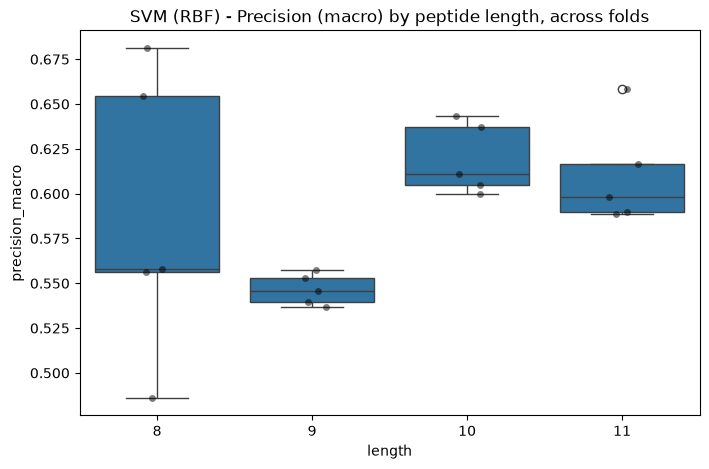

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

def plotModelPrecisionAcrossFolds(model, model_fold_indices, pipe):
    group_df = getMetricDfPerFold(model_fold_indices, pipe)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=group_df, x="length", y="precision_macro", ax=ax)
    sns.stripplot(data=group_df, x="length", y="precision_macro", color='black', alpha=0.5, ax=ax)
    ax.set_title(f"{model} - Precision (macro) by peptide length, across folds")
    plt.show()

plotModelPrecisionAcrossFolds("SVM (RBF)", svm_fold_indices, pipe_rbf_scaled)

### RF & Gradient Boosting

In [ ]:
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
# from sklearn.model_selection import KFold, GridSearchCV
# from sklearn.pipeline import Pipeline
# import pandas as pd

# param_grid_rf  = {
#     "clf__n_estimators": [200, 500],
#     "clf__max_depth": [None, 10, 20],
#     "clf__min_samples_leaf": [1, 5],
# }
# param_grid_hgb = {
#     "clf__max_iter": [100, 200],
#     "clf__max_depth": [None, 10],
#     "clf__learning_rate": [0.05, 0.1],
# }

# pipe_rf  = Pipeline([("clf", RandomForestClassifier(random_state=0, class_weight="balanced", n_jobs=1))])
# pipe_hgb = Pipeline([("clf", HistGradientBoostingClassifier(random_state=0))])
# # Note: HistGradientBoostingClassifier has no class_weight param — see earlier note
# # on sample_weight if you want imbalance correction applied to it too

# # HistGradientBoostingClassifier has no class_weight parameter — unlike RF/LogReg/SVM, sklearn's boosting implementation doesn't support it directly. 
# # At your ~60/40 ratio this is a minor gap, but if you want to correct for it anyway, the usual workaround is passing sample_weight at .fit() time 
# # (computed via sklearn.utils.class_weight.compute_sample_weight) — Worth flagging since RF and SVM get imbalance correction "for free" via class_weight='balanced' 
# # and HGB doesn't — happy to add the sample_weight wiring if you want HGB to compete on equal footing.

# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# model_configs_tree = {
#     "rf":  (pipe_rf, param_grid_rf),
#     "hgb": (pipe_hgb, param_grid_hgb),
# }

# scoring = {
#     "accuracy": "accuracy",
#     "balanced_accuracy": "balanced_accuracy",
#     "precision_macro": "precision_macro",
#     "recall_macro": "recall_macro",
#     "f1_macro": "f1_macro",
# }
# REFIT_METRIC = "precision_macro"

# results_tree = []

# for model_name, (pipe, grid) in model_configs_tree.items():
#     clf = GridSearchCV(
#         estimator=pipe,
#         param_grid=grid,
#         cv=cv,
#         scoring=scoring,
#         refit=REFIT_METRIC,
#         n_jobs=-1,
#         return_train_score=True,
#     )
#     clf.fit(X, y)  # unscaled only

#     best_index = clf.best_index_

#     for metric_name in scoring:
#         fold_scores = [
#             clf.cv_results_[f"split{i}_test_{metric_name}"][best_index]
#             for i in range(cv.get_n_splits())
#         ]
#         for fold_idx, score in enumerate(fold_scores):
#             results_tree.append({
#                 "model": model_name,
#                 "dataset": "unscaled",
#                 "fold": fold_idx,
#                 "metric": metric_name,
#                 "score": score,
#                 "best_params": str(clf.best_params_),
#             })

#     print(f"Done: {model_name} (best params: {clf.best_params_})")

# results_tree_df = pd.DataFrame(results_tree)
# print(results_tree_df)

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

param_grid_rf  = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5],
}
param_grid_hgb = {
    "clf__max_iter": [100, 200],
    "clf__max_depth": [None, 10],
    "clf__learning_rate": [0.05, 0.1],
}

# RandomForestClassifier cannot handle NaNs natively -> needs the imputer in-pipeline
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clf", RandomForestClassifier(random_state=0, class_weight="balanced", n_jobs=1)),
])

# HistGradientBoostingClassifier natively supports NaNs (it learns an optimal
# split direction for missing values per split), so imputation isn't required.
# I've left it out here to let HGB use its native handling rather than
# overriding it with a median fill -- native handling is generally at least
# as good and preserves the "missingness" information implicitly through its
# split logic without needing an explicit indicator column.
pipe_hgb = Pipeline([("clf", HistGradientBoostingClassifier(random_state=0))])

# ------------------------------------------------------------------
# Composite stratification key: class label + exact peptide length
# ------------------------------------------------------------------
assert len(X_df) == X.shape[0] == len(y)

lengths = X_df['length'].to_numpy()
strata = pd.Series(y).astype(str) + "_" + pd.Series(lengths).astype(str)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
forest_fold_indices = list(cv.split(X, strata))

model_configs_tree = {
    "rf":  (pipe_rf, param_grid_rf),
    "hgb": (pipe_hgb, param_grid_hgb),
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
REFIT_METRIC = "precision_macro"

results_tree = []

for model_name, (pipe, grid) in model_configs_tree.items():
    clf = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=forest_fold_indices,          # pre-computed stratified folds, not the cv object itself
        scoring=scoring,
        refit=REFIT_METRIC,
        n_jobs=-1,
        return_train_score=True,
    )
    clf.fit(X, y)  # unscaled -- trees don't need feature scaling

    best_index = clf.best_index_

    for metric_name in scoring:
        forest_fold_scores = [
            clf.cv_results_[f"split{i}_test_{metric_name}"][best_index]
            for i in range(n_splits)
        ]
        for fold_idx, score in enumerate(forest_fold_scores):
            results_tree.append({
                "model": model_name,
                "dataset": "unscaled",
                "fold": fold_idx,
                "metric": metric_name,
                "score": score,
                "best_params": str(clf.best_params_),
            })

    print(f"Done: {model_name} (best params: {clf.best_params_})")

results_tree_df = pd.DataFrame(results_tree)
#print(results_tree_df)

Done: rf (best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500})
Done: hgb (best params: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_iter': 100})


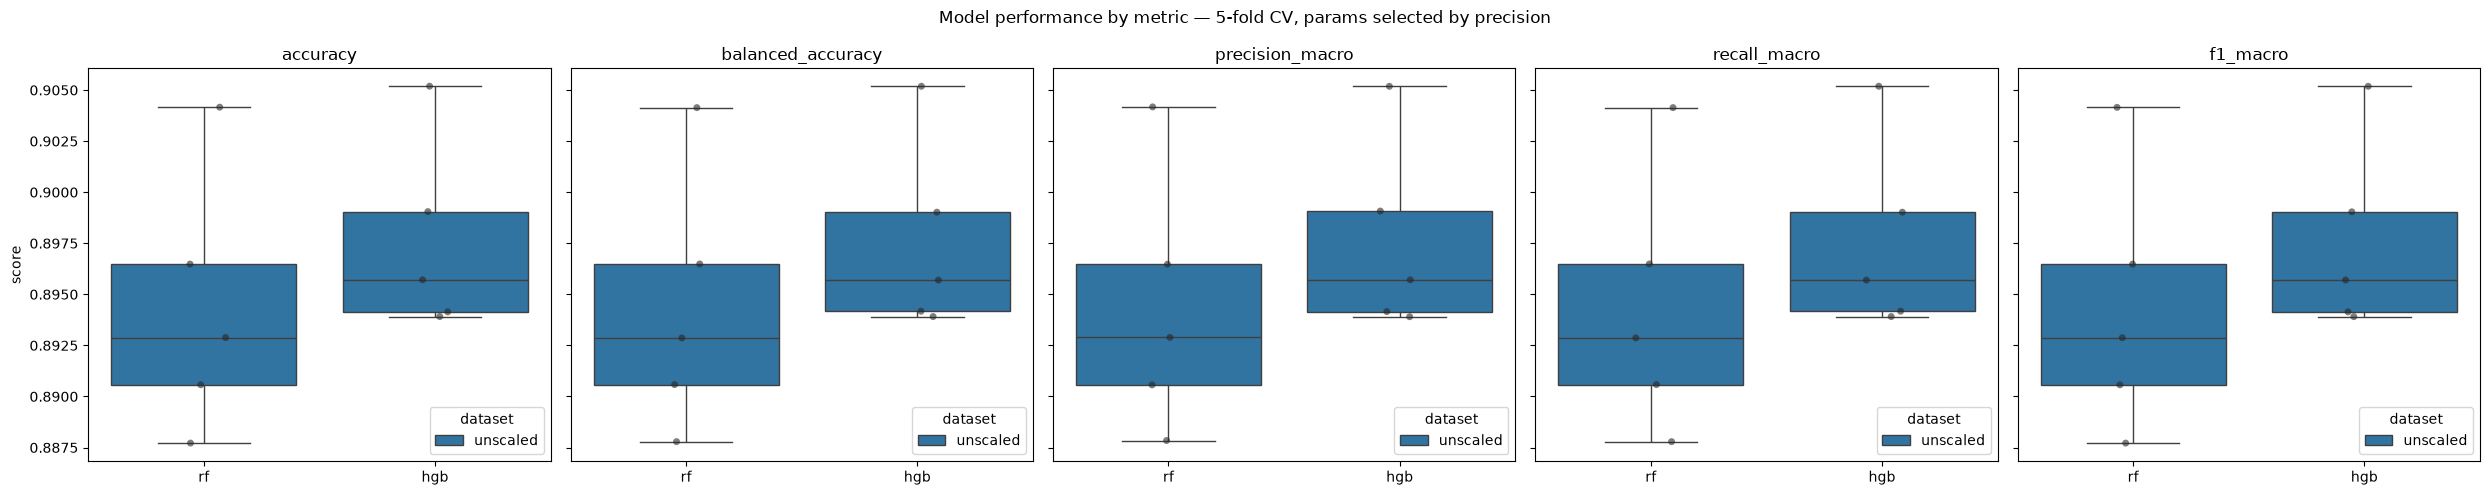

In [397]:
plotModels(results_tree_df)

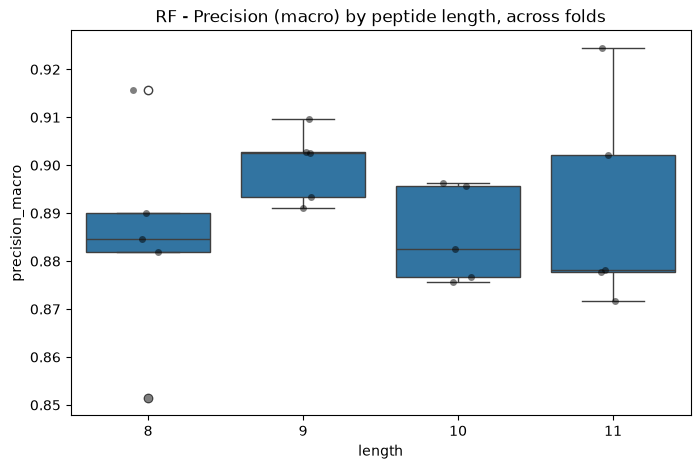

In [398]:
plotModelPrecisionAcrossFolds("RF", forest_fold_indices, pipe_rf)

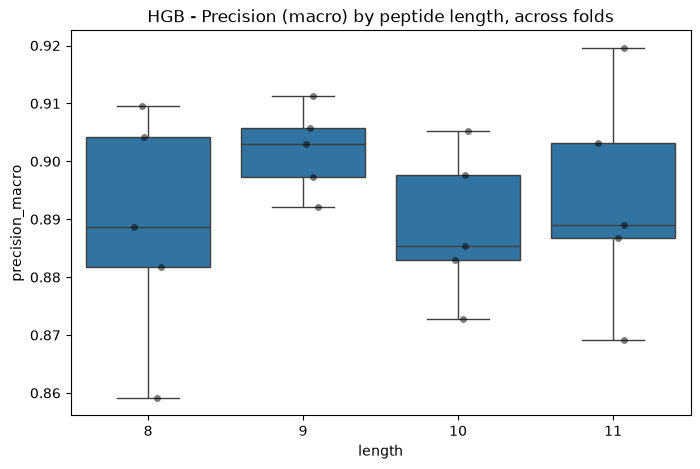

In [399]:
plotModelPrecisionAcrossFolds("HGB", forest_fold_indices, pipe_hgb)

## Logistic Regression

In [415]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd

param_grid_logreg = {"clf__C": [0.1, 1, 10]}

pipe_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clf", LogisticRegression(random_state=0, max_iter=5000, class_weight="balanced"))])

#cv = KFold(n_splits=5, shuffle=True, random_state=42)
assert len(X_df) == X.shape[0] == len(y)

lengths = X_df['length'].to_numpy()
strata = pd.Series(y).astype(str) + "_" + pd.Series(lengths).astype(str)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
linreg_fold_indices = list(cv.split(X, strata))

datasets = {
    # "unscaled": X,
    "scaled_robust": X_scaled_Robust,
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
REFIT_METRIC = "precision_macro"

results_logreg = []

for data_name, X_data in datasets.items():
    clf = GridSearchCV(
        estimator=pipe_logreg,
        param_grid=param_grid_logreg,
        cv=linreg_fold_indices,
        scoring=scoring,
        refit=REFIT_METRIC,
        n_jobs=-1,
        return_train_score=True,
    )
    clf.fit(X_data, y)

    best_index = clf.best_index_

    for metric_name in scoring:
        fold_scores = [
            clf.cv_results_[f"split{i}_test_{metric_name}"][best_index]
            for i in range(cv.get_n_splits())
        ]
        for fold_idx, score in enumerate(fold_scores):
            results_logreg.append({
                "model": "logreg",
                "dataset": data_name,
                "fold": fold_idx,
                "metric": metric_name,
                "score": score,
                "best_params": str(clf.best_params_),
            })

    print(f"Done: logreg / {data_name} (best params: {clf.best_params_})")

results_logreg_df = pd.DataFrame(results_logreg)
print(results_logreg_df)

Done: logreg / scaled_robust (best params: {'clf__C': 0.1})
     model        dataset  fold             metric     score      best_params
0   logreg  scaled_robust     0           accuracy  0.594103  {'clf__C': 0.1}
1   logreg  scaled_robust     1           accuracy  0.588974  {'clf__C': 0.1}
2   logreg  scaled_robust     2           accuracy  0.590769  {'clf__C': 0.1}
3   logreg  scaled_robust     3           accuracy  0.594872  {'clf__C': 0.1}
4   logreg  scaled_robust     4           accuracy  0.592973  {'clf__C': 0.1}
5   logreg  scaled_robust     0  balanced_accuracy  0.594257  {'clf__C': 0.1}
6   logreg  scaled_robust     1  balanced_accuracy  0.589053  {'clf__C': 0.1}
7   logreg  scaled_robust     2  balanced_accuracy  0.590966  {'clf__C': 0.1}
8   logreg  scaled_robust     3  balanced_accuracy  0.595185  {'clf__C': 0.1}
9   logreg  scaled_robust     4  balanced_accuracy  0.593143  {'clf__C': 0.1}
10  logreg  scaled_robust     0    precision_macro  0.594358  {'clf__C': 0.1}
11  

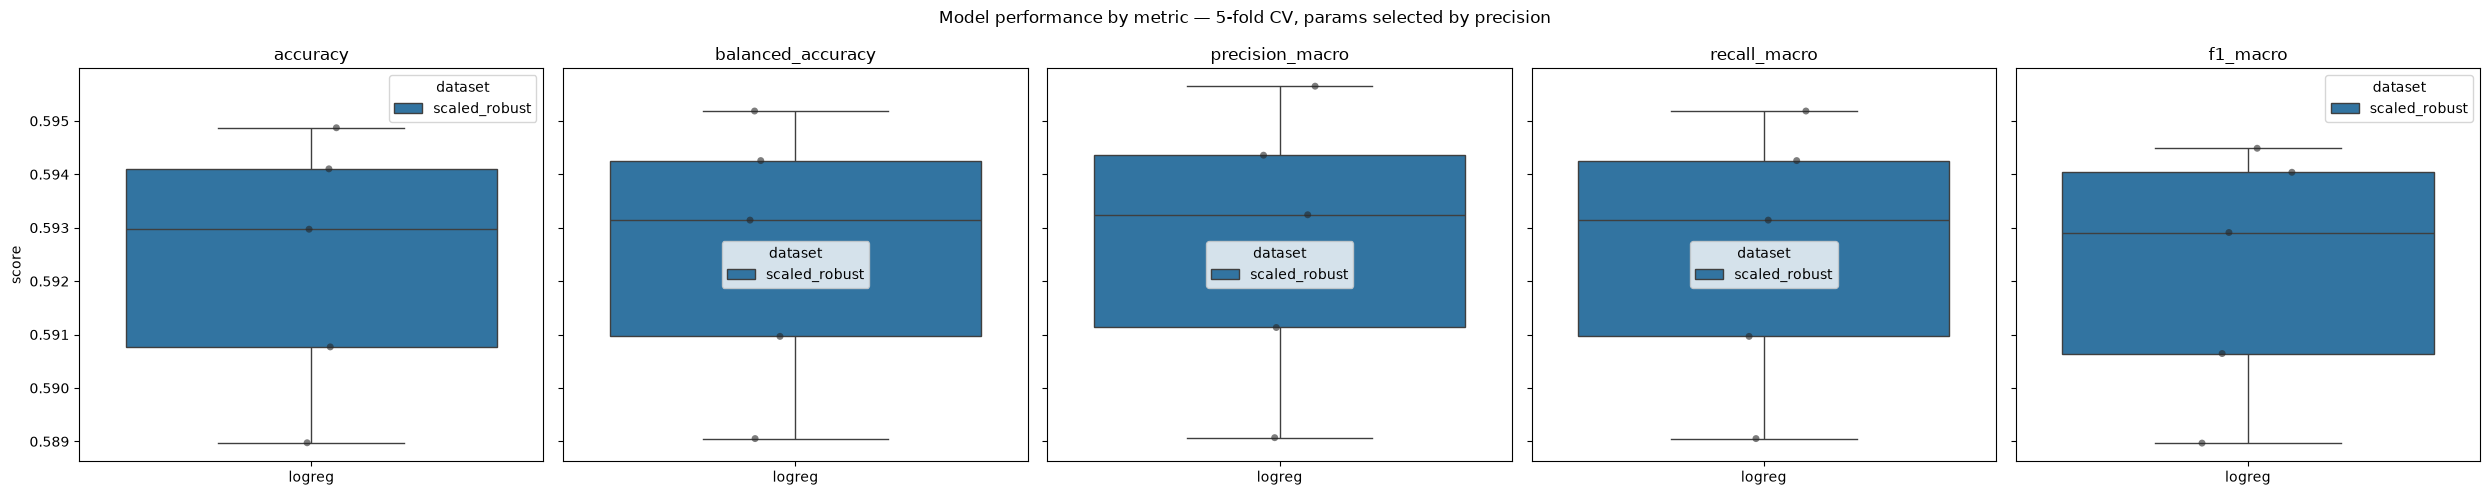

In [416]:
plotModels(results_logreg_df)

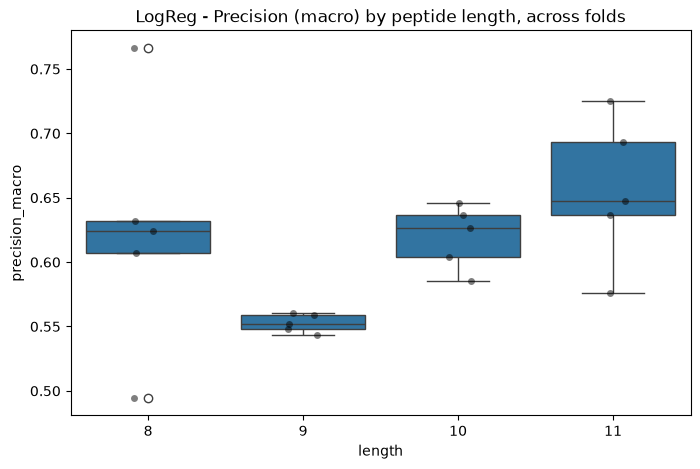

In [417]:
plotModelPrecisionAcrossFolds("LogReg", linreg_fold_indices, pipe_logreg)

### Saving Models

In [ ]:
import joblib
import sklearn
import json
from datetime import datetime, timezone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def save_metadata(pipe, filepath, clf='clf', cv_results_df=None):
    metadata = {
        "sklearn_version": sklearn.__version__,
        "python_version": __import__("sys").version,
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "features": list(FINAL_FEATURES),
        "params": pipe.named_steps[f"{clf}"].get_params(),
        "n_train_samples": len(X),
    }
    if cv_results_df is not None:
        metadata["cv_results_summary"] = cv_results_df.groupby("metric")["score"].mean().to_dict()
    with open(filepath, "w") as f:
        json.dump(metadata, f, indent=2, default=str)


final_pipe_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
    ("svc", CalibratedClassifierCV(svm.SVC(kernel="rbf", C=1, gamma=0.1, random_state=0), ensemble=False)),
])
final_pipe_svm.fit(X, y)
joblib.dump(final_pipe_svm, f"{MODEL_SAVING_DIR}/svm_rbf_pipeline.joblib")
save_metadata(final_pipe_svm, f"{MODEL_SAVING_DIR}/svm_rbf_pipeline_metadata.json")

# --- Random Forest ---
final_pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clf", RandomForestClassifier(max_depth=None, min_samples_leaf=1, n_estimators=500, random_state=0)),
])
final_pipe_rf.fit(X, y)
joblib.dump(final_pipe_rf, f"{MODEL_SAVING_DIR}/rf_pipeline.joblib")
save_metadata(final_pipe_rf, f"{MODEL_SAVING_DIR}/rf_pipeline_metadata.json")

# --- HistGradientBoosting ---
final_pipe_hgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clf", HistGradientBoostingClassifier(learning_rate=0.1, max_depth=None, max_iter=100, random_state=0)),
])
final_pipe_hgb.fit(X, y)
joblib.dump(final_pipe_hgb, f"{MODEL_SAVING_DIR}/hgb_pipeline.joblib")
save_metadata(final_pipe_hgb, f"{MODEL_SAVING_DIR}/hgb_pipeline_metadata.json")


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill

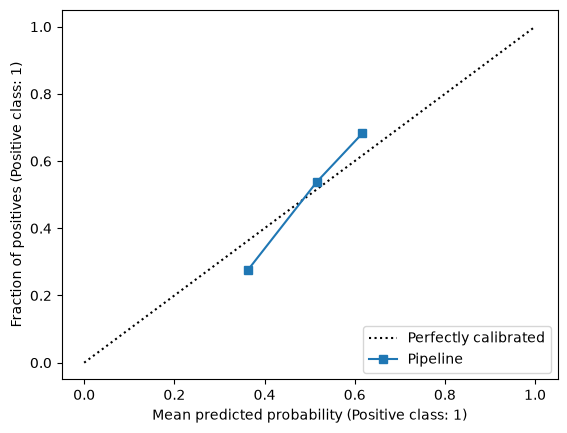

In [70]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

CalibrationDisplay.from_estimator(final_pipe_svm, X_test, y_test)
plt.show()

### Original MEssy Code

In [66]:
# C = 1.0  # SVM regularization parameter
# models = (
#     svm.SVC(kernel="linear", C=C),
#     svm.LinearSVC(C=C, max_iter=10000),
#     svm.SVC(kernel="rbf", gamma=0.7, C=C),
#     svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
# )
# models = (clf.fit(X, y) for clf in models)

scoring = ['precision_macro', 'recall_macro']
clf = svm.SVC(kernel="rbf", gamma=0.7, C=1)
#clf = svm.LinearSVC(C=10, random_state=0, max_iter=10000)
scores = cross_validate(clf, X, y, scoring=scoring, n_jobs=-1)
sorted(scores.keys())

scores_scaled = cross_validate(clf, X_scaled_Robust, y, scoring=scoring, n_jobs=-1)


In [67]:
print(f'Precision: {scores_scaled["test_precision_macro"]}')

print(f'Recall: {scores_scaled["test_recall_macro"]}')

Precision: [0.64606976 0.63055878 0.63086395 0.663751   0.63840516]
Recall: [0.62143061 0.61372619 0.58887863 0.62641334 0.62136094]


In [651]:
from sklearn.metrics import classification_report, precision_score, recall_score

clf = svm.LinearSVC(C=10, random_state=0, max_iter=10000)
clf.fit(X_scaled_train, y_train) 

y_test_pred = clf.predict(X_test)

print("Test precision (macro):", precision_score(y_test, y_test_pred, average='macro'))
print("Test recall (macro):", recall_score(y_test, y_test_pred, average='macro'))
print()
print(classification_report(y_test, y_test_pred))

display(X_validation_scaled_robust)

y_preds = clf.predict(X_validation_scaled_robust)

print(y_preds[0:20])

Test precision (macro): 0.2494871794871795
Test recall (macro): 0.5

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1954
           1       0.50      1.00      0.67      1946

    accuracy                           0.50      3900
   macro avg       0.25      0.50      0.33      3900
weighted avg       0.25      0.50      0.33      3900



/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

array([[-5.63276754e-01, -8.61182241e-01,  1.45000000e+02, ...,
         9.19288314e-01,  1.00000000e+00,  4.80283671e-01],
       [-5.46448087e-01, -8.01615529e-01,  2.40000000e+01, ...,
         6.16387433e-01,  0.00000000e+00,  2.59216238e-02],
       [-5.61664813e-01, -8.57954333e-01,  8.60000000e+01, ...,
         1.18809262e+00,  1.00000000e+00, -1.49905239e-01],
       ...,
       [-5.64114964e-01, -8.66370513e-01,  1.46000000e+02, ...,
        -9.90805934e-01,  0.00000000e+00,  1.33251819e+00],
       [-5.64243919e-01, -8.67567201e-01,  1.69000000e+02, ...,
        -2.03657613e-01,  0.00000000e+00,  9.57632818e-01],
       [-5.63728098e-01, -8.66094960e-01,  1.19000000e+02, ...,
        -7.71407346e-01,  0.00000000e+00,  1.01241059e+00]],
      shape=(19499, 14))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
scoring = ['precision', 'recall']
#clf = svm.SVC(kernel='linear', C=10, random_state=0)
clf = svm.SVC(kernel='rbf', C=10, random_state=0, gamma=0.1)
scores = cross_validate(clf, X, y, scoring=scoring, n_jobs=-1)
sorted(scores.keys())

scores_scaled = cross_validate(clf, X_scaled_Robust, y, scoring=scoring, n_jobs=-1)

In [70]:
print("Test Scores")

display(f"Precision: {scores['test_precision_macro']}")
display(f"Recall: {scores['test_recall_macro']}")
display("Scaled")
display(f"Precision: {scores_scaled['test_precision_macro']}")
display(f"Recall: {scores_scaled['test_recall_macro']}")

Test Scores


'Precision: [0.63555237 0.60357726 0.61505448 0.6350752  0.62018101]'

'Recall: [0.6181935  0.5968254  0.59264569 0.61048857 0.60906955]'

'Scaled'

'Precision: [0.65239137 0.63593667 0.61790108 0.66358361 0.63592861]'

'Recall: [0.61736975 0.61366689 0.57419045 0.62360237 0.6106961 ]'

In [455]:
# # Number of random trials
# NUM_TRIALS = 2

# # Set up possible values of parameters to optimize over
# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1]}

# # We will use a Support Vector Classifier with "rbf" kernel
# svc = svm.SVC(kernel="rbf")

# # Arrays to store scores
# nested_scores = np.zeros(NUM_TRIALS)

# # Loop for each trial
# for i in range(NUM_TRIALS):
#     # Choose cross-validation techniques for the inner and outer loops,
#     # independently of the dataset.
#     # E.g "GroupKFold", "LeaveOneOut", "LeaveOneGroupOut", etc.
#     inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
#     outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

#     # Nested CV with parameter optimization
#     clf = GridSearchCV(estimator=svc, param_grid=p_grid, cv=inner_cv)
#     nested_score = cross_val_score(clf, X=X_scaled_train, y=y_train, cv=outer_cv)
#     nested_scores[i] = nested_score.mean()

In [ ]:
print(X.shape)
print(y.shape)

from sklearn.utils import resample
X_sample, y_sample = resample(X, y, n_samples=500, random_state=42)


(19499, 22)
(19499,)
(19499, 22)
(19499,)


In [68]:
from sklearn import svm
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Parameter grid: each dict is its own independent search space,
# so gamma is only tested with kernels that actually use it.
# ------------------------------------------------------------------
p_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"],    "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]},
    #{"svc__kernel": ["poly"],   "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1], "svc__degree": [2, 3]},
]

# ------------------------------------------------------------------
# Wrap in a Pipeline. Best practice even if scaling is already done —
# it also makes adding preprocessing steps later trivial.
# The svc__ prefix in p_grid above maps to the pipeline step name.
# ------------------------------------------------------------------
pipe = Pipeline([("svc", svm.SVC())])

# ------------------------------------------------------------------
# Nested CV — single pass, no repeated trials
# ------------------------------------------------------------------
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv  = KFold(n_splits=5, shuffle=True, random_state=42)

clf = GridSearchCV(
    estimator=pipe,
    param_grid=p_grid,
    cv=inner_cv,
    scoring="precision",
    n_jobs=-1,
    refit=True,                    # refit best model on the full inner fold data
    return_train_score=True,       # lets you diagnose overfitting later
    verbose=1
)

nested_scores = cross_val_score(clf, X=X, y=y, cv=outer_cv, scoring="precision")

print(f"Nested CV precision: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

In [130]:
# ------------------------------------------------------------------
# Identify the best hyperparameters: refit GridSearchCV on the 
# full training set so you can inspect best_params_ and best_score_
# ------------------------------------------------------------------
clf.fit(X_sample, y_sample)

print(f"\nBest params:  {clf.best_params_}")
print(f"Best inner CV score: {clf.best_score_:.4f}")

# ------------------------------------------------------------------
# Summary table of all candidates — useful for comparing kernels
# ------------------------------------------------------------------
results_df = pd.DataFrame(clf.cv_results_)[
    ["param_svc__kernel", "param_svc__C", "param_svc__gamma", "param_svc__degree",
     "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")

print("\nTop 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))

print("\nBottom 10 parameter combinations:")
print(results_df.tail(10).to_string(index=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:  {'svc__C': 10, 'svc__kernel': 'linear'}
Best inner CV score: 0.6360

Top 10 parameter combinations:
param_svc__kernel  param_svc__C  param_svc__gamma  param_svc__degree  mean_test_score  std_test_score  mean_train_score  rank_test_score
           linear          10.0               NaN                NaN            0.636        0.018547            0.6465                1
           linear           1.0               NaN                NaN            0.632        0.016000            0.6425                2
           linear           0.1               NaN                NaN            0.626        0.028705            0.6375                3
              rbf          10.0              0.01                NaN            0.624        0.025768            0.6720                4
              rbf           1.0              0.01                NaN            0.618        0.044000            0.6375                5
 